Figure 1. Biodiversity only

[rcp26_ssp1] 17% PA (2080 - 2015) -> Min: -70.13%, Max: 100.00%
[rcp26_ssp1] 30% PA ("biodiversity-only" - 17% PA 2080) -> Min: -61.37%, Max: 89.58%
[rcp26_ssp2] 17% PA (2080 - 2015) -> Min: -70.18%, Max: 100.00%
[rcp26_ssp2] 30% PA ("biodiversity-only" - 17% PA 2080) -> Min: -64.23%, Max: 100.00%
[rcp60_ssp4] 17% PA (2080 - 2015) -> Min: -73.33%, Max: 84.93%
[rcp60_ssp4] 30% PA ("biodiversity-only" - 17% PA 2080) -> Min: -55.77%, Max: 100.00%

✅ Figure saved at: /capacity/occr_davin/mguzman/chari_P2_review/Global/Previous_results/Figures/F1_Final_HighRes_Large.png


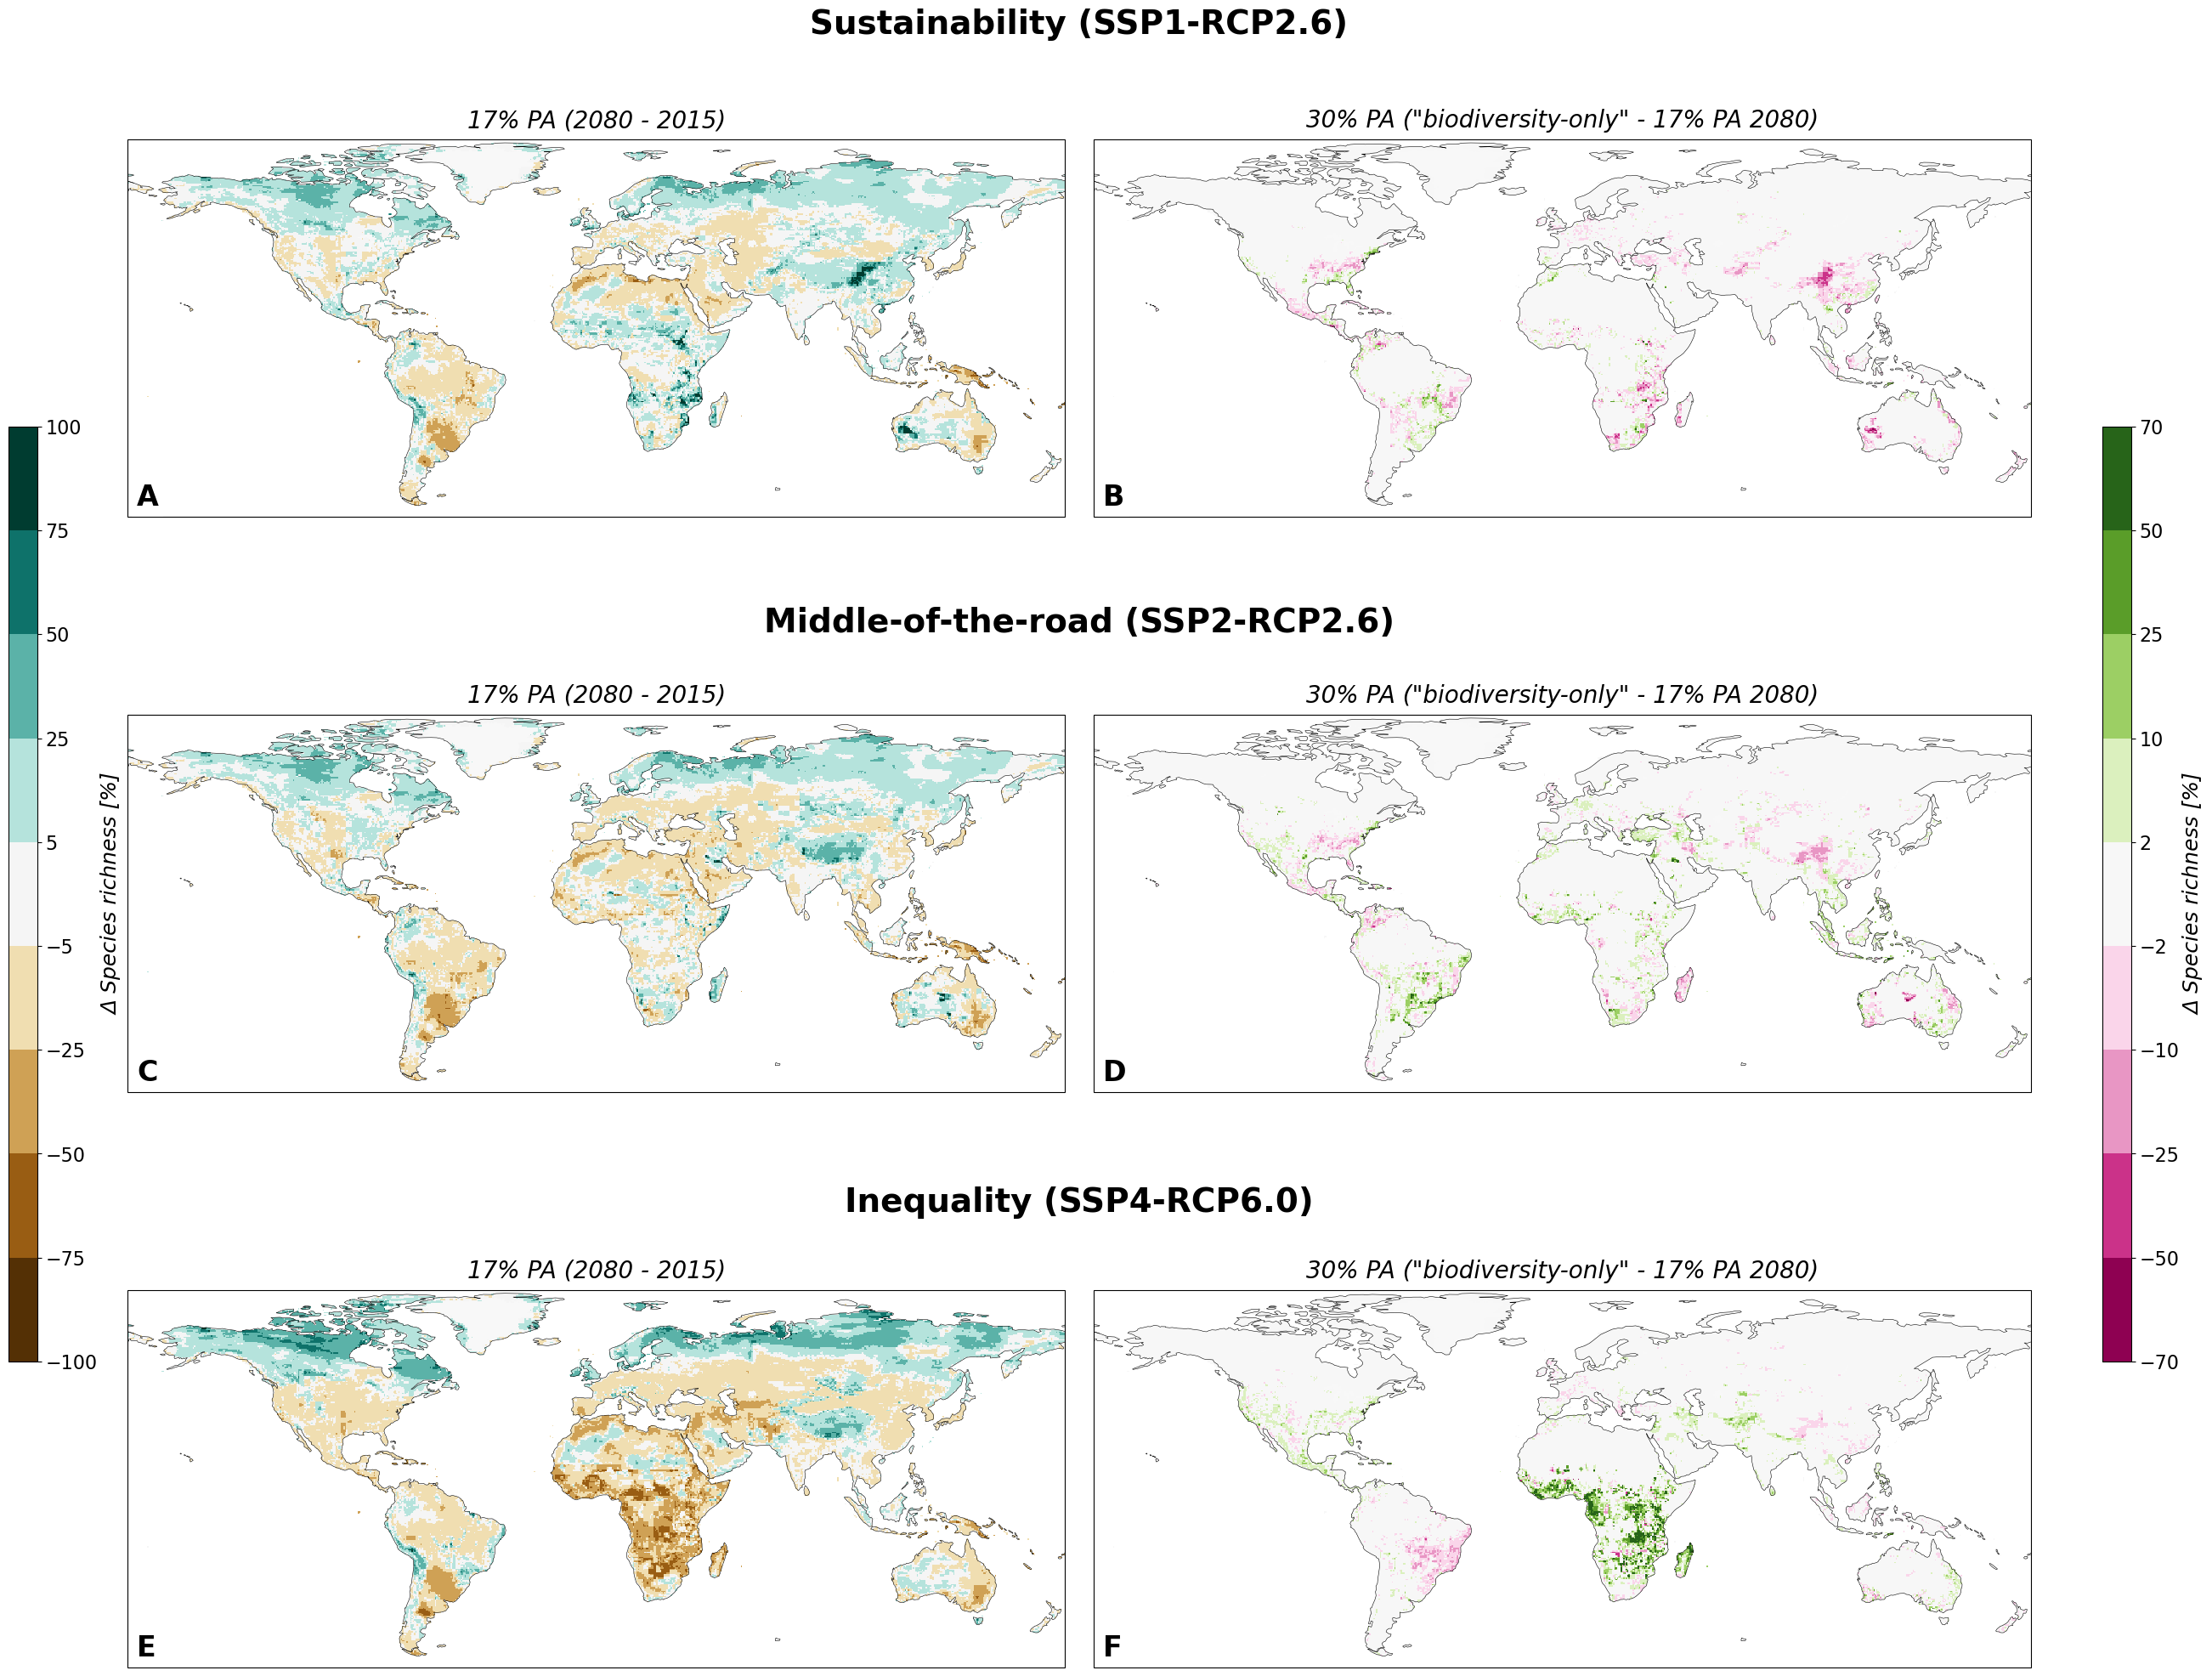

In [1]:
#!/usr/bin/env python3
import os
import warnings
import matplotlib.pyplot as plt
from matplotlib.colors import BoundaryNorm
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import numpy as np
import xarray as xr
import string

warnings.filterwarnings('ignore')

# --- 1. SETUP AND PATHS ---
HIST_FILE = "/capacity/occr_davin/mguzman/chari_P2_review/Global/PA_scenarios/Sumprob/WDPA/Historical/Ensembles/total_richness_historical_2015.nc"
BASE_DIR_WDPA = "/capacity/occr_davin/mguzman/chari_P2_review/Global/PA_scenarios/Sumprob/WDPA/Baseline/Ensembles"
BASE_DIR_BIO  = "/capacity/occr_davin/mguzman/chari_P2_review/Global/PA_scenarios/Sumprob/PA30_Bio_new/Ensembles"

OUTPUT_DIR = "/capacity/occr_davin/mguzman/chari_P2_review/Global/Previous_results/Figures"
os.makedirs(OUTPUT_DIR, exist_ok=True)
OUTPUT_PATH = os.path.join(OUTPUT_DIR, "F1_Final_HighRes_Large.png")

scenarios = ['rcp26_ssp1', 'rcp26_ssp2', 'rcp60_ssp4']
scenario_titles = {
    "rcp26_ssp1": "Sustainability (SSP1-RCP2.6)",
    "rcp26_ssp2": "Middle-of-the-road (SSP2-RCP2.6)",
    "rcp60_ssp4": "Inequality (SSP4-RCP6.0)"
}

PLOT_COLS = {
    0: {'title': '17% PA (2080 - 2015)', 'calc': ('strict', 'hist')},
    1: {'title': '30% PA ("biodiversity-only" - 17% PA 2080)', 'calc': ('pa30_bio', 'strict')},
}

# Define alphabet for panel labeling (a, b, c, d, e, f)
alphabet = string.ascii_uppercase

# --- 2. HELPERS ---
def fix_coords(ds):
    if ds is None: return None
    if 'longitude' in ds.coords: ds = ds.rename({'longitude': 'lon'})
    if 'latitude' in ds.coords: ds = ds.rename({'latitude': 'lat'})
    if ds.lon.max() > 180:
        ds = ds.assign_coords(lon=(((ds.lon + 180) % 360) - 180))
    return ds.sortby(['lat', 'lon'])

def load_data_file(config_type, scen_key):
    clim_rcp, lu_ssp_short = scen_key.split('_')
    ssp_map = {"ssp1": "ssp126", "ssp2": "ssp245", "ssp4": "ssp460"}
    lu_ssp = ssp_map[lu_ssp_short]

    if config_type == 'hist':
        path = HIST_FILE
    else:
        base, prefix = (BASE_DIR_WDPA, "baseline") if config_type == 'strict' else (BASE_DIR_BIO, "pa30_bio")
        # Logic to handle naming conventions on the cluster
        if lu_ssp == "ssp245":
            fname = f"total_richness_{prefix}_clim_{clim_rcp}_LU_{lu_ssp}_2080.nc"
        else:
            fname = f"total_richness_{prefix}_{clim_rcp}_2080.nc"
        path = os.path.join(base, fname)

    if not os.path.exists(path): return None
    try:
        ds = xr.open_dataset(path, decode_times=False)
        return fix_coords(ds['prob_clim_disp_luf'].squeeze()).compute()
    except: return None

# --- 3. PLOTTING SETUP ---
boundaries_left = [-100, -75, -50, -25, -5, 5, 25, 50, 75, 100]
cmap_left = plt.get_cmap('BrBG', len(boundaries_left)-1)
norm_left = BoundaryNorm(boundaries_left, cmap_left.N)

# Updated for Column 2 (30% PA) to capture the -60% minimums
boundaries_right = [-70, -50, -25, -10, -2, 2, 10, 25, 50, 70]
cmap_right = plt.get_cmap('PiYG', len(boundaries_right)-1)
norm_right = BoundaryNorm(boundaries_right, cmap_right.N)

fig, axes = plt.subplots(nrows=3, ncols=2, figsize=(28, 22),
                         subplot_kw={'projection': ccrs.PlateCarree()})

plt.subplots_adjust(left=0.08, right=0.88, top=0.94, bottom=0.05, hspace=0.12, wspace=0.03)

im_left = None
im_right = None

# --- 4. PROCESSING LOOP ---
for row_idx, scen_key in enumerate(scenarios):
    # Centered Scenario Titles
    y_pos = [0.96, 0.64, 0.33] 
    fig.text(0.48, y_pos[row_idx], scenario_titles[scen_key], 
             fontsize=28, fontweight='bold', ha='center')

    for col_idx in range(2):
        ax = axes[row_idx, col_idx]
        col_params = PLOT_COLS[col_idx]
        
        m_future = load_data_file(col_params['calc'][0], scen_key)
        m_ref = load_data_file(col_params['calc'][1], scen_key)

        if m_future is not None and m_ref is not None:
            threshold = 0.01
            valid_ref = m_ref.where(m_ref > threshold)
            diff_data = (((m_future - valid_ref) / valid_ref) * 100).clip(-100, 100)

            # --- INTERNAL TERMINAL OUTPUT ---
            # Extract scalar values for records
            p_min = float(diff_data.min())
            p_max = float(diff_data.max())
            print(f"[{scen_key}] {col_params['title']} -> Min: {p_min:.2f}%, Max: {p_max:.2f}%")

            # Plotting logic
            curr_cmap, curr_norm = (cmap_left, norm_left) if col_idx == 0 else (cmap_right, norm_right)

            im = ax.pcolormesh(diff_data.lon, diff_data.lat, diff_data.values,
                               transform=ccrs.PlateCarree(), cmap=curr_cmap, 
                               norm=curr_norm, shading='auto')
            
            if col_idx == 0: im_left = im
            else: im_right = im

            # Map Aesthetics
            ax.set_extent([-180, 180, -60, 85], crs=ccrs.PlateCarree())
            ax.add_feature(cfeature.LAND, facecolor='#f8f8f8', zorder=0)
            ax.coastlines(color="black", linewidth=0.4)
            ax.set_title(col_params['title'], fontsize=20, pad=10, style='italic')

            # Alphabet Labels (a, b, c...)
            label_idx = row_idx * 2 + col_idx
            ax.text(0.01, 0.03, alphabet[label_idx], transform=ax.transAxes,
                    fontsize=24, fontweight='bold', 
                    bbox=dict(facecolor='white', alpha=0.5, edgecolor='none'))

# --- 5. COLORBARS ---
if im_left:
    cax1 = fig.add_axes([0.03, 0.25, 0.012, 0.5]) 
    cb1 = fig.colorbar(im_left, cax=cax1, orientation='vertical', ticks=boundaries_left)
    cb1.set_label('Δ Species richness [%]', fontsize=18, style='italic')
    cb1.ax.tick_params(labelsize=16)

if im_right:
    cax2 = fig.add_axes([0.91, 0.25, 0.012, 0.5]) 
    cb2 = fig.colorbar(im_right, cax=cax2, orientation='vertical', ticks=boundaries_right)
    cb2.set_label('Δ Species richness [%]', fontsize=18, style='italic')
    cb2.ax.tick_params(labelsize=16)

plt.savefig(OUTPUT_PATH, dpi=500, bbox_inches='tight')
print(f"\n✅ Figure saved at: {OUTPUT_PATH}")

Figure 1. Multi-objective (biodiversity conservation, carbon sequestration and water regulation)

[rcp26_ssp1] 17% PA (2080 - 2015) -> Min: -70.13%, Max: 100.00%
[rcp26_ssp1] 30% PA ("multi-objective" - 17% PA 2080) -> Min: -53.57%, Max: 100.00%
[rcp26_ssp2] 17% PA (2080 - 2015) -> Min: -70.18%, Max: 100.00%
[rcp26_ssp2] 30% PA ("multi-objective" - 17% PA 2080) -> Min: -48.23%, Max: 100.00%
[rcp60_ssp4] 17% PA (2080 - 2015) -> Min: -73.33%, Max: 84.93%
[rcp60_ssp4] 30% PA ("multi-objective" - 17% PA 2080) -> Min: -56.74%, Max: 100.00%

✅ Figure saved at: /capacity/occr_davin/mguzman/chari_P2_review/Global/Previous_results/Figures/F1_Final_HighRes_Large.png


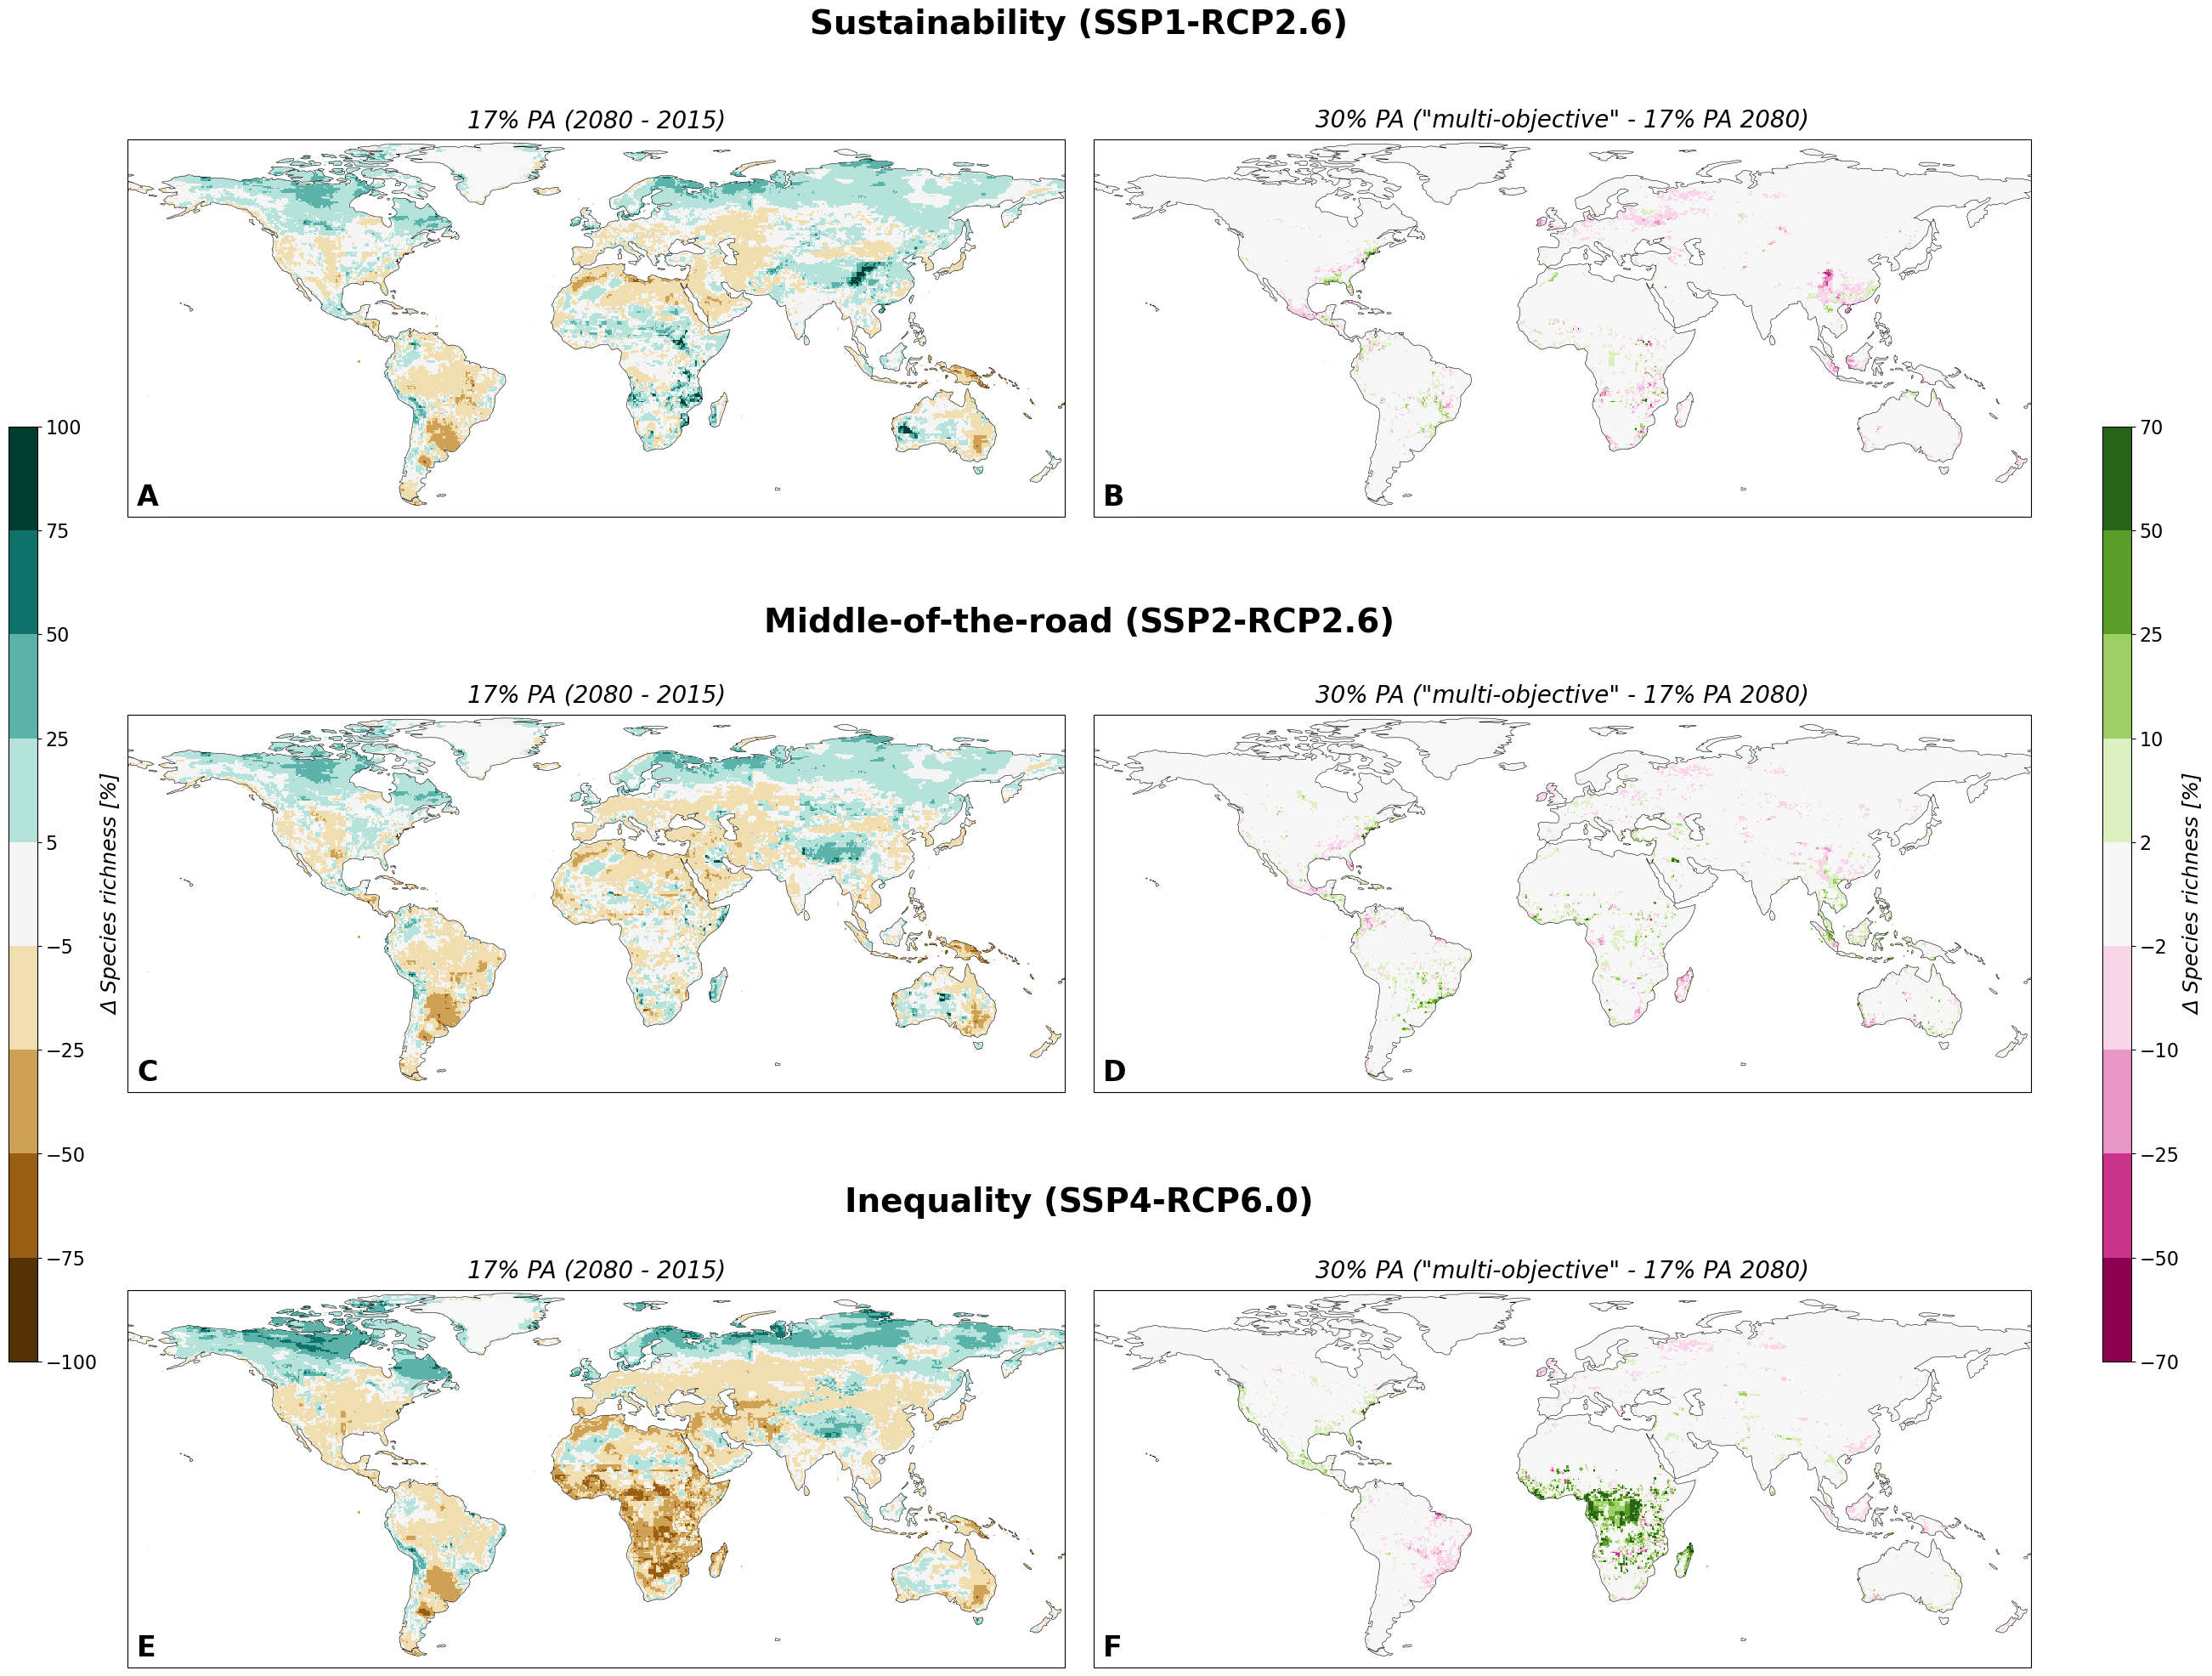

In [5]:
#!/usr/bin/env python3
import os
import warnings
import matplotlib.pyplot as plt
from matplotlib.colors import BoundaryNorm
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import numpy as np
import xarray as xr
import string

warnings.filterwarnings('ignore')

# --- 1. SETUP AND PATHS ---
HIST_FILE = "/capacity/occr_davin/mguzman/chari_P2_review/Global/PA_scenarios/Sumprob/WDPA/Historical/Ensembles/total_richness_historical_2015.nc"
BASE_DIR_WDPA = "/capacity/occr_davin/mguzman/chari_P2_review/Global/PA_scenarios/Sumprob/WDPA/Baseline/Ensembles"
BASE_DIR_BCW  = "/capacity/occr_davin/mguzman/chari_P2_review/Global/PA_scenarios/Sumprob/PA30_BCW_new/Ensembles"

OUTPUT_DIR = "/capacity/occr_davin/mguzman/chari_P2_review/Global/Previous_results/Figures"
os.makedirs(OUTPUT_DIR, exist_ok=True)
OUTPUT_PATH = os.path.join(OUTPUT_DIR, "F1_Final_HighRes_Large.png")

scenarios = ['rcp26_ssp1', 'rcp26_ssp2', 'rcp60_ssp4']
scenario_titles = {
    "rcp26_ssp1": "Sustainability (SSP1-RCP2.6)",
    "rcp26_ssp2": "Middle-of-the-road (SSP2-RCP2.6)",
    "rcp60_ssp4": "Inequality (SSP4-RCP6.0)"
}

PLOT_COLS = {
    0: {'title': '17% PA (2080 - 2015)', 'calc': ('strict', 'hist')},
    1: {'title': '30% PA ("multi-objective" - 17% PA 2080)', 'calc': ('pa30_bcw', 'strict')},
}

# Define alphabet for panel labeling (a, b, c, d, e, f)
alphabet = string.ascii_uppercase

# --- 2. HELPERS ---
def fix_coords(ds):
    if ds is None: return None
    if 'longitude' in ds.coords: ds = ds.rename({'longitude': 'lon'})
    if 'latitude' in ds.coords: ds = ds.rename({'latitude': 'lat'})
    if ds.lon.max() > 180:
        ds = ds.assign_coords(lon=(((ds.lon + 180) % 360) - 180))
    return ds.sortby(['lat', 'lon'])

def load_data_file(config_type, scen_key):
    clim_rcp, lu_ssp_short = scen_key.split('_')
    ssp_map = {"ssp1": "ssp126", "ssp2": "ssp245", "ssp4": "ssp460"}
    lu_ssp = ssp_map[lu_ssp_short]

    if config_type == 'hist':
        path = HIST_FILE
    else:
        base, prefix = (BASE_DIR_WDPA, "baseline") if config_type == 'strict' else (BASE_DIR_BCW, "pa30_bcw")
        # Logic to handle naming conventions on the cluster
        if lu_ssp == "ssp245":
            fname = f"total_richness_{prefix}_clim_{clim_rcp}_LU_{lu_ssp}_2080.nc"
        else:
            fname = f"total_richness_{prefix}_{clim_rcp}_2080.nc"
        path = os.path.join(base, fname)

    if not os.path.exists(path): return None
    try:
        ds = xr.open_dataset(path, decode_times=False)
        return fix_coords(ds['prob_clim_disp_luf'].squeeze()).compute()
    except: return None

# --- 3. PLOTTING SETUP ---
boundaries_left = [-100, -75, -50, -25, -5, 5, 25, 50, 75, 100]
cmap_left = plt.get_cmap('BrBG', len(boundaries_left)-1)
norm_left = BoundaryNorm(boundaries_left, cmap_left.N)

# Updated for Column 2 (30% PA) to capture the -60% minimums
boundaries_right = [-70, -50, -25, -10, -2, 2, 10, 25, 50, 70]
cmap_right = plt.get_cmap('PiYG', len(boundaries_right)-1)
norm_right = BoundaryNorm(boundaries_right, cmap_right.N)

fig, axes = plt.subplots(nrows=3, ncols=2, figsize=(28, 22),
                         subplot_kw={'projection': ccrs.PlateCarree()})

plt.subplots_adjust(left=0.08, right=0.88, top=0.94, bottom=0.05, hspace=0.12, wspace=0.03)

im_left = None
im_right = None

# --- 4. PROCESSING LOOP ---
for row_idx, scen_key in enumerate(scenarios):
    # Centered Scenario Titles
    y_pos = [0.96, 0.64, 0.33] 
    fig.text(0.48, y_pos[row_idx], scenario_titles[scen_key], 
             fontsize=28, fontweight='bold', ha='center')

    for col_idx in range(2):
        ax = axes[row_idx, col_idx]
        col_params = PLOT_COLS[col_idx]
        
        m_future = load_data_file(col_params['calc'][0], scen_key)
        m_ref = load_data_file(col_params['calc'][1], scen_key)

        if m_future is not None and m_ref is not None:
            threshold = 0.01
            valid_ref = m_ref.where(m_ref > threshold)
            diff_data = (((m_future - valid_ref) / valid_ref) * 100).clip(-100, 100)

            # --- INTERNAL TERMINAL OUTPUT ---
            # Extract scalar values for records
            p_min = float(diff_data.min())
            p_max = float(diff_data.max())
            print(f"[{scen_key}] {col_params['title']} -> Min: {p_min:.2f}%, Max: {p_max:.2f}%")

            # Plotting logic
            curr_cmap, curr_norm = (cmap_left, norm_left) if col_idx == 0 else (cmap_right, norm_right)

            im = ax.pcolormesh(diff_data.lon, diff_data.lat, diff_data.values,
                               transform=ccrs.PlateCarree(), cmap=curr_cmap, 
                               norm=curr_norm, shading='auto')
            
            if col_idx == 0: im_left = im
            else: im_right = im

            # Map Aesthetics
            ax.set_extent([-180, 180, -60, 85], crs=ccrs.PlateCarree())
            ax.add_feature(cfeature.LAND, facecolor='#f8f8f8', zorder=0)
            ax.coastlines(color="black", linewidth=0.4)
            ax.set_title(col_params['title'], fontsize=20, pad=10, style='italic')

            # Alphabet Labels (a, b, c...)
            label_idx = row_idx * 2 + col_idx
            ax.text(0.01, 0.03, alphabet[label_idx], transform=ax.transAxes,
                    fontsize=24, fontweight='bold', 
                    bbox=dict(facecolor='white', alpha=0.5, edgecolor='none'))

# --- 5. COLORBARS ---
if im_left:
    cax1 = fig.add_axes([0.03, 0.25, 0.012, 0.5]) 
    cb1 = fig.colorbar(im_left, cax=cax1, orientation='vertical', ticks=boundaries_left)
    cb1.set_label('Δ Species richness [%]', fontsize=18, style='italic')
    cb1.ax.tick_params(labelsize=16)

if im_right:
    cax2 = fig.add_axes([0.91, 0.25, 0.012, 0.5]) 
    cb2 = fig.colorbar(im_right, cax=cax2, orientation='vertical', ticks=boundaries_right)
    cb2.set_label('Δ Species richness [%]', fontsize=18, style='italic')
    cb2.ax.tick_params(labelsize=16)

plt.savefig(OUTPUT_PATH, dpi=500, bbox_inches='tight')
print(f"\n✅ Figure saved at: {OUTPUT_PATH}")

FIGURE 2

30%-PA "biodiversity-only". Optimization scenario from Jung et al. (2021).

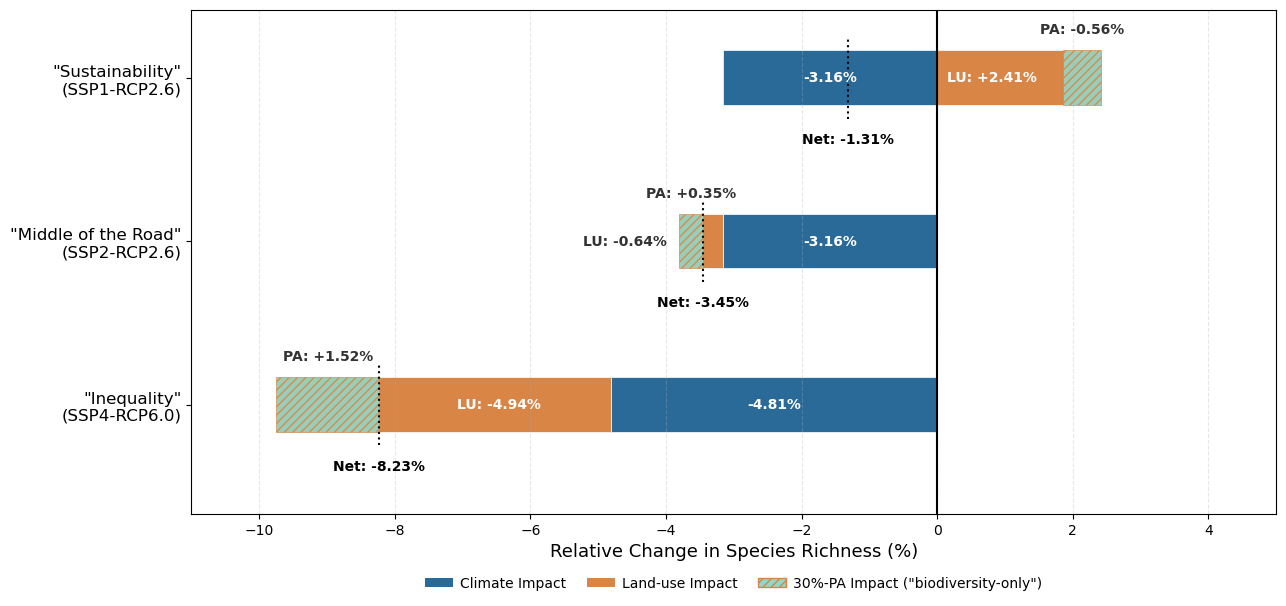

In [9]:
import os
import xarray as xr
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patheffects as path_effects
from matplotlib.patches import Patch

# --- 1. SETTINGS & PATHS ---
WDPA_ROOT = "/capacity/occr_davin/mguzman/chari_P2_review/Global/PA_scenarios/Sumprob/WDPA"
BIO_ROOT = "/capacity/occr_davin/mguzman/chari_P2_review/Global/PA_scenarios/Sumprob/PA30_Bio_new"

scen_configs = [
    ('rcp26', 'ssp126'), 
    ('rcp26', 'ssp245'), 
    ('rcp60', 'ssp460')
]


def get_weighted_mean(ds, weights):
    var = 'prob_clim_disp_luf'
    return ds[var].weighted(weights).mean(dim=['lat', 'lon']).item()

# --- 2. DATA PROCESSING ---
ds_hist = xr.open_dataset(os.path.join(WDPA_ROOT, "Historical/Ensembles/total_richness_historical_2015.nc"))
weights = np.cos(np.deg2rad(ds_hist.lat))
h_val = get_weighted_mean(ds_hist, weights)

results = []
for clim_sce, lu_sce in scen_configs:
    if lu_sce == 'ssp245':
        f_base, f_clim, f_bio = f"total_richness_baseline_clim_{clim_sce}_LU_{lu_sce}_2080.nc", f"total_richness_climate_only_clim_{clim_sce}_LU_{lu_sce}_2080.nc", f"total_richness_pa30_bio_clim_{clim_sce}_LU_{lu_sce}_2080.nc"
        label = f"\"Middle of the Road\"\n(SSP2-RCP2.6)"
    else:
        f_base, f_clim, f_bio = f"total_richness_baseline_{clim_sce}_2080.nc", f"total_richness_climate_only_{clim_sce}_2080.nc", f"total_richness_pa30_bio_{clim_sce}_2080.nc"
        label = "\"Sustainability\"\n(SSP1-RCP2.6)" if lu_sce == 'ssp126' else "\"Inequality\"\n(SSP4-RCP6.0)"

    ds_clim = xr.open_dataset(os.path.join(WDPA_ROOT, f"Climate_Only/Ensembles/{f_clim}"))
    ds_base = xr.open_dataset(os.path.join(WDPA_ROOT, f"Baseline/Ensembles/{f_base}"))
    ds_bio  = xr.open_dataset(os.path.join(BIO_ROOT,  f"Ensembles/{f_bio}"))
    
    c_val, b_val, bio_val = get_weighted_mean(ds_clim, weights), get_weighted_mean(ds_base, weights), get_weighted_mean(ds_bio, weights)

    results.append({
        'Label': label,
        'Climate': (c_val - h_val) / h_val * 100,
        'Land Use': (b_val - c_val) / h_val * 100,
        'Exp_Bio': (bio_val - b_val) / h_val * 100
    })

df = pd.DataFrame(results)

# --- 3. PLOTTING WITH ZERO-ANCHORED LOGIC ---
fig, ax = plt.subplots(figsize=(14, 8))
y_pos = np.array([2.4, 1.2, 0.0]) 
width = 0.4
colors = {'Climate': '#2a6a98', 'Land Use': '#d88546', 'Exp_Bio': '#92d8c8'}

for i, row in df.iterrows():
    y = y_pos[i]
    lu_val, pa_val, clim_val = row['Land Use'], row['Exp_Bio'], row['Climate']

    # 1. Climate: Standard anchor at 0
    ax.barh(y, clim_val, left=0, height=width, color=colors['Climate'], edgecolor='white', linewidth=0.5)
    ax.text(clim_val / 2, y, f"{clim_val:+.2f}%", va='center', ha='center', color='white', fontweight='bold')

    # 2. Land Use: If negative, stack after climate; if positive, start at 0
    lu_start = clim_val if lu_val < 0 else 0
    ax.barh(y, lu_val, left=lu_start, height=width, color=colors['Land Use'], edgecolor='white', linewidth=0.5)
    
    # LU Label Logic
    if abs(lu_val) > 1.8:
        ax.text(lu_start + lu_val/3, y, f"LU: {lu_val:+.2f}%", va='center', ha='center', color='white', fontweight='bold')
    else:
        # Move label down to avoid clashing with centered climate/PA text
        ax.text(lu_start + lu_val - 0.8, y, f"LU: {lu_val:+.2f}%", va='center', ha='center', color='#333333', fontweight='bold')

    # 3. Expansion (PA): Stacks at the end of Land Use
    pa_start = lu_start + lu_val
    is_internalized = (lu_val > 0 and pa_val < 0) or (lu_val < 0 and pa_val > 0)
    
    ax.barh(y, pa_val, left=pa_start, height=width, color=colors['Exp_Bio'], 
            hatch='////' if is_internalized else None, 
            edgecolor=colors['Land Use'] if is_internalized else 'white', 
            alpha=0.9, linewidth=0.5)

    # PA Label Logic
    if abs(pa_val) > 1.2 and not is_internalized:
        ax.text(pa_start + pa_val/3, y, f"PA: {pa_val:+.2f}%", va='right', ha='right', color='#333333', fontweight='bold')
    else:
        # Shift PA label higher to prevent it from sitting on the Net dashed line
        pa_x = pa_start + pa_val/2
        ax.text(pa_x, y + 0.30, f"PA: {pa_val:+.2f}%", va='bottom', ha='center', color='#333333', fontweight='bold')

    # 4. Net Value
    net_val = clim_val + lu_val + pa_val
    ax.vlines(x=net_val, ymin=y - 0.3, ymax=y + 0.3, color='black', linestyle=':', linewidth=1.5)
    
    # Net Label
    ax.text(net_val, y - 0.4, f"Net: {net_val:+.2f}%", ha='center', va='top', fontweight='black', fontsize=10)

# Legend and Aesthetics
ax.axvline(0, color='black', linewidth=1.2)

legend_elements = [
    Patch(facecolor=colors['Climate'], label='Climate Impact'),
    Patch(facecolor=colors['Land Use'], label='Land-use Impact'),
    Patch(facecolor=colors['Exp_Bio'], hatch='////', 
          edgecolor=colors['Land Use'], label='30%-PA Impact ("biodiversity-only")')
]

ax.legend(handles=legend_elements, 
          loc='upper center', 
          bbox_to_anchor=(0.5, -0.1), 
          ncol=3, 
          frameon=False, 
          fontsize=10,
          handletextpad=0.5,   
          columnspacing=1.5) 

# Aesthetics
ax.axvline(0, color='black', linewidth=1.5)
ax.set_yticks(y_pos)
ax.set_yticklabels(df['Label'], fontsize=12)
ax.set_xlabel('Relative Change in Species Richness (%)', fontsize=13)
ax.set_xlim(-11, 5)
ax.set_ylim(y_pos.min() - 0.8, y_pos.max() + 0.5)
ax.grid(axis='x', linestyle='--', alpha=0.3)

# --- 2. ADD LEGEND TO AXIS ---
plt.subplots_adjust(bottom=0.25)
plt.show()


In [ ]:
import os
import xarray as xr
import numpy as np
import pandas as pd

# --- 1. SETTINGS ---
BASE_PATH = "/capacity/occr_davin/mguzman/chari_P2_review/Global/PA_scenarios/Sumprob"
ROOT_BIO_NEW = "/capacity/occr_davin/mguzman/chari_P2_review/Global/PA_scenarios/Sumprob/PA30_Bio_new"

TAXAS = ["Amphibians", "Bird", "Mammals"]
GCMS = ["GFDL-ESM2M", "IPSL-CM5A-LR", "HadGEM2-ES", "MIROC5"]
SDMS = ["GAM", "GBM"]

# Mapping for scenario-specific filename segments
scen_configs = [
    ('rcp26', 'ssp126', ""),            # Sustainability
    ('rcp26', 'ssp245', "_LU_ssp245"),  # Middle of the Road
    ('rcp60', 'ssp460', "")             # Inequality
]

# --- 2. HISTORICAL TOTAL (2015 Anchor) ---
h_total = 0
for t in TAXAS:
    h_file = os.path.join(BASE_PATH, f"WDPA/Historical/Ensembles/{t}_historical_2015.nc")
    with xr.open_dataset(h_file) as ds:
        weights = np.cos(np.deg2rad(ds.lat))
        h_total += ds['prob_clim_disp_luf'].weighted(weights).mean().item()

# --- 3. CALCULATE SNAPSHOTS ---
results = []

for rcp, ssp, lu_tag in scen_configs:
    model_results = []
    
    for sdm in SDMS:
        for gcm in GCMS:
            m_clim, m_base, m_bio = 0, 0, 0
            found_all_taxa = True
            
            for t in TAXAS:
                use_sdm = sdm
                
                # Constructing filenames with the scenario-specific LU tag
                f_clim_name = f"summed_prob_{t}_{use_sdm}_{gcm}_{rcp}_2080{lu_tag}_clim_only.nc"
                f_base_name = f"summed_prob_{t}_{use_sdm}_{gcm}_{rcp}_2080{lu_tag}_wdpa17.nc"
                f_bio_name  = f"summed_prob_{t}_{use_sdm}_{gcm}_{rcp}_2080{lu_tag}_pa30_bio.nc"

                f_clim = os.path.join(BASE_PATH, "WDPA/Climate_Only", f_clim_name)
                f_base = os.path.join(BASE_PATH, "WDPA/Baseline", f_base_name)
                f_bio  = os.path.join(ROOT_BIO_NEW, f_bio_name)

                if all(os.path.exists(f) for f in [f_clim, f_base, f_bio]):
                    with xr.open_dataset(f_clim) as ds: m_clim += ds['prob_clim_disp_luf'].weighted(weights).mean().item()
                    with xr.open_dataset(f_base) as ds: m_base += ds['prob_clim_disp_luf'].weighted(weights).mean().item()
                    with xr.open_dataset(f_bio) as ds:  m_bio  += ds['prob_clim_disp_luf'].weighted(weights).mean().item()
                else:
                    found_all_taxa = False

            if found_all_taxa:
                model_results.append({
                    'Climate_pct': (m_clim - h_total) / h_total * 100,
                    'LU_cont': (m_base - m_clim) / h_total * 100,
                    'PA_cont': (m_bio - m_base) / h_total * 100
                })

    if model_results:
        m_df = pd.DataFrame(model_results)
        results.append({
            'Scenario': f"{ssp}-{rcp}",
            'Climate_Mean': m_df['Climate_pct'].mean(),
            'Climate_SE': m_df['Climate_pct'].sem(),
            'LU_Mean': m_df['LU_cont'].mean(),
            'LU_SE': m_df['LU_cont'].sem(),
            'PA_Mean': m_df['PA_cont'].mean(),
            'PA_SE': m_df['PA_cont'].sem()
        })

df_final = pd.DataFrame(results)
print(df_final)

       Scenario  Climate_Mean  Climate_SE   LU_Mean     LU_SE   PA_Mean  \
0  ssp126-rcp26     -3.164039    0.639404  2.409400  0.014555 -0.557153   
1  ssp245-rcp26     -3.164039    0.639404 -0.644750  0.006381  0.354459   
2  ssp460-rcp60     -4.810480    0.674839 -4.939999  0.023506  1.524459   

      PA_SE  
0  0.003282  
1  0.004775  
2  0.007107  


Figure 3. Subregional analysis (Management effectiveness)

PA scenarios: 17% PA, 30%-PA biodiversity-only and 30%-PA multi-objective under SSP1-RCP2.6 and SSP4-RCP6.0. Results for the 17 IPBES Subregions

Processing rcp26...
Processing rcp60...


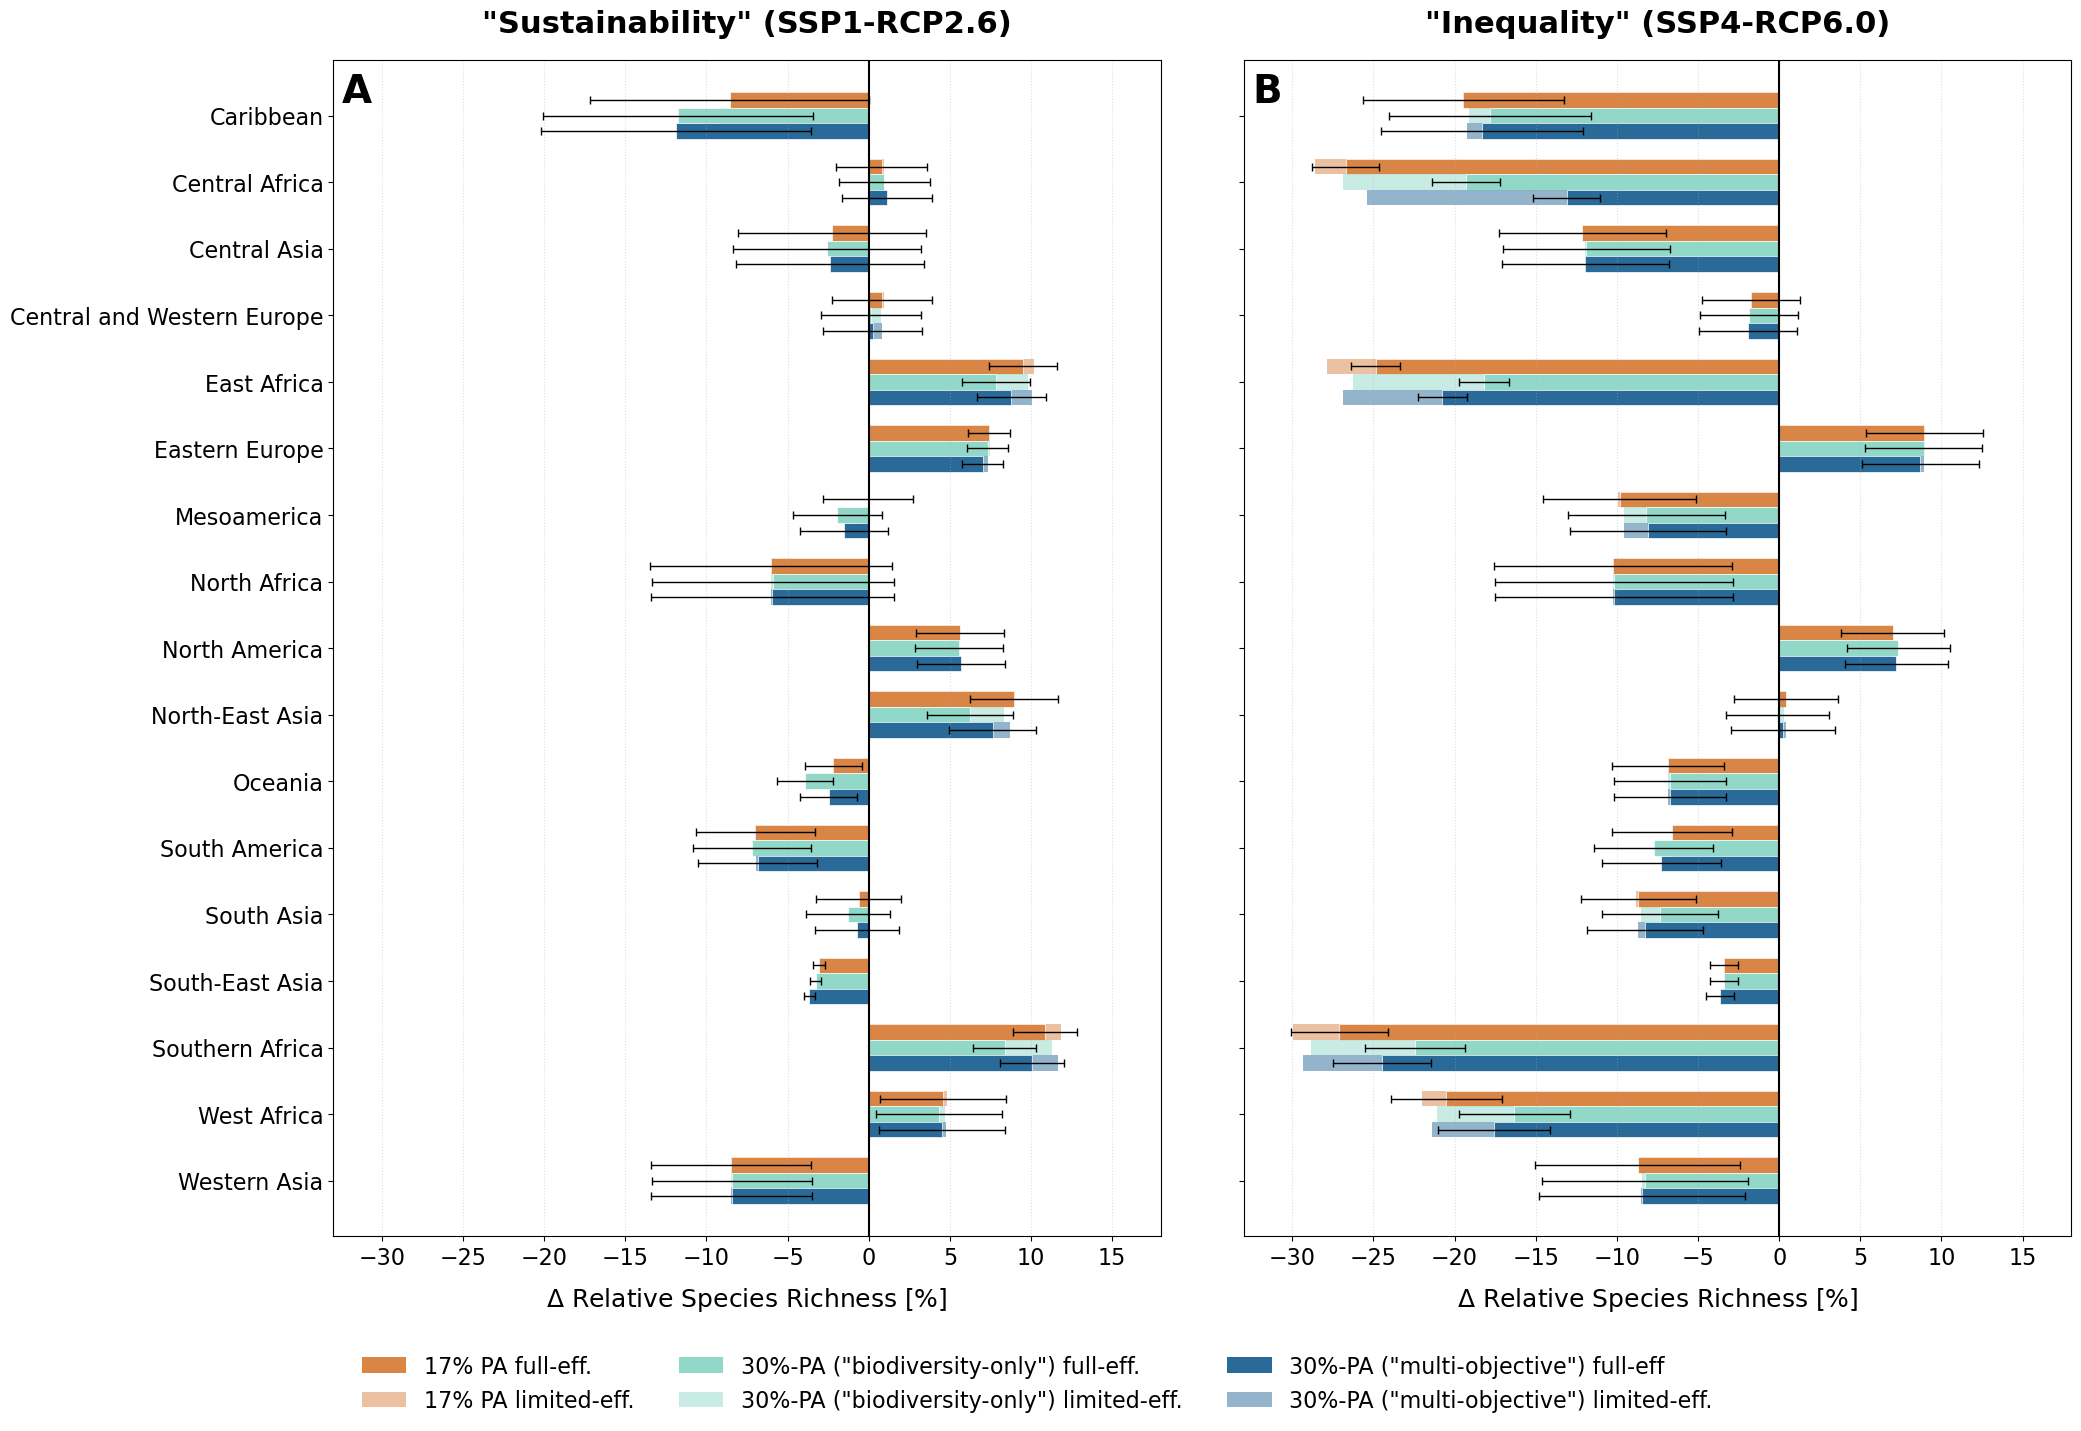

In [ ]:
import os
import xarray as xr
import geopandas as gpd
import pandas as pd
import numpy as np
from rasterio import features
from affine import Affine
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from matplotlib.lines import Line2D 

# --- 1. CONFIGURATION ---
BASE_PATH = "/capacity/occr_davin/mguzman/chari_P2_review/Global/PA_scenarios/Sumprob"
SHP_PATH  = "/capacity/occr_davin/chari/P1/IPBES_subregions/IPBES_Regions_Subregions2.shp"
TAXAS = ["Amphibians", "Bird", "Mammals"]
SDMS = ["GAM", "GBM"]
GCMS = ["GFDL-ESM2M", "IPSL-CM5A-LR", "HadGEM2-ES", "MIROC5"]
SCENARIOS = ["rcp26", "rcp60"]

# Categories and their specific folder/suffix 
CAT_CONFIG = {
    "17": ("WDPA/Baseline", "wdpa17"),
    "bio": ("PA30_Bio_new", "pa30_bio"),
    "bcw": ("PA30_BCW_new", "pa30_bcw")
}

# --- 2. GRID & WEIGHTS ---
hist_f = os.path.join(BASE_PATH, "WDPA/Baseline/Ensembles/total_richness_baseline_rcp26_2080.nc") # Using as template
ds_hist = xr.open_dataset(os.path.join(BASE_PATH, "WDPA/Historical/Ensembles/total_richness_historical_2015.nc"))['prob_clim_disp_luf'].load()

res_lon = (ds_hist.lon[1] - ds_hist.lon[0]).item()
res_lat = (ds_hist.lat[1] - ds_hist.lat[0]).item()
transform = Affine.translation(ds_hist.lon[0] - res_lon/2, ds_hist.lat[0] - res_lat/2) * Affine.scale(res_lon, res_lat)

lat_weights = np.cos(np.deg2rad(ds_hist.lat.values))
global_weights = np.broadcast_to(lat_weights[:, np.newaxis], ds_hist.shape)

shp = gpd.read_file(SHP_PATH)
region_mapping = {
    'Caribbean': 'Caribbean', 'Central Africa': 'Central Africa',
    'Central and Western Europe': 'Central and Western Europe', 'Central Asia': 'Central Asia',
    'East Africa and adjacent islands': 'East Africa', 'Eastern Europe': 'Eastern Europe',
    'Mesoamerica': 'Mesoamerica', 'North Africa': 'North Africa',
    'North America': 'North America', 'North-East Asia': 'North-East Asia',
    'Oceania': 'Oceania', 'South America': 'South America', 'South Asia': 'South Asia',
    'South-East Asia': 'South-East Asia', 'Southern Africa': 'Southern Africa',
    'West Africa': 'West Africa', 'Western Asia': 'Western Asia'
}
shp['new_region'] = shp['Sub_Region'].map(region_mapping)
unique_regions = sorted(shp['new_region'].dropna().unique())
region_masks = {r: features.rasterize(shp[shp['new_region'] == r].geometry, 
                out_shape=ds_hist.shape, transform=transform, fill=0, default_value=1).astype(bool) 
                for r in unique_regions}

# --- 3. DATA EXTRACTION ---
results_full = {s: {c: {r: [] for r in unique_regions} for c in CAT_CONFIG} for s in SCENARIOS}
results_lim = {s: {c: {r: [] for r in unique_regions} for c in CAT_CONFIG} for s in SCENARIOS}

for sce in SCENARIOS:
    print(f"Processing {sce}...")
    for cat_key, (sub_dir, suffix) in CAT_CONFIG.items():
        base_dir = os.path.join(BASE_PATH, sub_dir)
        
        for sdm in SDMS:
            for gcm in GCMS:
                member_sum_f, member_sum_l = None, None
                
                for taxa in TAXAS:
                    current_sdm = sdm
                    f_full = os.path.join(base_dir, f"summed_prob_{taxa}_{current_sdm}_{gcm}_{sce}_2080_{suffix}.nc")
                    f_lim = os.path.join(base_dir, f"lim_eff_summed_prob_{taxa}_{current_sdm}_{gcm}_{sce}_2080_{suffix}.nc")

                    if os.path.exists(f_full):
                        with xr.open_dataset(f_full) as ds:
                            data = ds['prob_clim_disp_luf'].load()
                            member_sum_f = data if member_sum_f is None else member_sum_f + data
                    
                    if os.path.exists(f_lim):
                        with xr.open_dataset(f_lim) as ds:
                            data_l = ds['prob_clim_disp_luf'].load()
                            member_sum_l = data_l if member_sum_l is None else member_sum_l + data_l

                
                if member_sum_f is not None:
                    diff = ((member_sum_f - ds_hist) / ds_hist.where(ds_hist > 0)) * 100
                    for r in unique_regions:
                        mask = region_masks[r]
                        # Flatten to check values
                        m_vals = diff.values[mask]
                        w_vals = global_weights[mask]
                        valid = ~np.isnan(m_vals)
                        if valid.any():
                            results_full[sce][cat_key][r].append(np.average(m_vals[valid], weights=w_vals[valid]))

                if member_sum_l is not None:
                    diff_l = ((member_sum_l - ds_hist) / ds_hist.where(ds_hist > 0)) * 100
                    for r in unique_regions:
                        mask = region_masks[r]
                        m_vals = diff_l.values[mask]
                        w_vals = global_weights[mask]
                        valid = ~np.isnan(m_vals)
                        if valid.any():
                            results_lim[sce][cat_key][r].append(np.average(m_vals[valid], weights=w_vals[valid]))

# --- 4. PLOTTING ---
fig, axes = plt.subplots(1, 2, figsize=(22, 14), sharey=True) 
colors = {'17': '#d88546', 'bio': '#92d8c8', 'bcw': '#2a6a98'}

bar_width = 0.28
indices = np.arange(len(unique_regions)) * 1.2 
offsets = [-bar_width, 0, bar_width]
titles = {"rcp26": '"Sustainability" (SSP1-RCP2.6)', "rcp60": '"Inequality" (SSP4-RCP6.0)'}

for i, sce in enumerate(SCENARIOS):
    ax = axes[i]
    for idx, c in enumerate(['17', 'bio', 'bcw']):
        m_f = [np.mean(results_full[sce][c][r]) if results_full[sce][c][r] else 0 for r in unique_regions]
        s_f = [np.std(results_full[sce][c][r], ddof=1) if len(results_full[sce][c][r]) > 1 else 0 for r in unique_regions]
        m_l = [np.mean(results_lim[sce][c][r]) if results_lim[sce][c][r] else 0 for r in unique_regions]
        
        y_pos = indices + offsets[idx]
        
        # Plot Limited Effectiveness (Ghosted background)
        ax.barh(y_pos, m_l, bar_width, color=colors[c], alpha=0.5)
        
        # Plot Full Effectiveness (Primary bars)
        ax.barh(y_pos, m_f, bar_width, color=colors[c], xerr=s_f, 
                error_kw={'capsize': 3, 'elinewidth': 1, 'alpha': 1.0},
                edgecolor='white', linewidth=0.5)

    # Styling for clarity and scale
    ax.set_yticks(indices)
    if i == 0:
        ax.set_yticklabels(unique_regions, fontsize=16, fontweight='medium')
    
    ax.set_title(titles[sce], fontsize=22, pad=20, fontweight='bold')
    ax.invert_yaxis()
    
    # Force -50 to 50 for clarity
    ax.set_xlim(-33, 18)
    ax.set_xticks([-30, -25, -20, -15, -10, -5, 0, 5, 10, 15])
    ax.tick_params(axis='x', 
                   labelsize=16)
    
    ax.grid(axis='x', linestyle=':', alpha=0.4, zorder=0)
    ax.axvline(0, color='black', lw=1.5, zorder=3)
    ax.set_xlabel(r'$\Delta$ Relative Species Richness [%]', fontsize=18, labelpad=12)
    
    
    # Tighten vertical space to prevent "floating" labels
    ax.set_ylim(indices[-1] + 1, indices[0] - 1)
    
    # Panel labels consistent with previous figures
    ax.text(0.01, 0.99, ['A', 'B'][i], transform=ax.transAxes, 
            fontsize=28, fontweight='bold', va='top')

# Legend with descriptive labels for PA scenarios
legend_elements = [
    Patch(facecolor=colors['17'], alpha=1.0, label='17% PA full-eff.'),
    Patch(facecolor=colors['17'], alpha=0.5, label='17% PA limited-eff.'),
    Patch(facecolor=colors['bio'], alpha=1.0, label='30%-PA ("biodiversity-only") full-eff.'),
    Patch(facecolor=colors['bio'], alpha=0.5, label='30%-PA ("biodiversity-only") limited-eff.'),
    Patch(facecolor=colors['bcw'], alpha=1.0, label='30%-PA ("multi-objective") full-eff'),
    Patch(facecolor=colors['bcw'], alpha=0.5, label='30%-PA ("multi-objective") limited-eff.')
]

fig.legend(handles=legend_elements, loc='lower center', ncol=3, 
           bbox_to_anchor=(0.5, -0.06), fontsize=16, frameon=False)

plt.subplots_adjust(left=0.18, right=0.97, top=0.92, bottom=0.08, wspace=0.1)
plt.show()

Table S1. Results per subregions, SSP-RCP scenario and PA scenario

In [ ]:
import os
import xarray as xr
import geopandas as gpd
import pandas as pd
import numpy as np
from rasterio import features
from affine import Affine

# --- 1. CONFIGURATION ---
BASE_PATH = "/capacity/occr_davin/mguzman/chari_P2_review/Global/PA_scenarios/Sumprob"
SHP_PATH  = "/capacity/occr_davin/chari/P1/IPBES_subregions/IPBES_Regions_Subregions2.shp"
TAXAS = ["Amphibians", "Bird", "Mammals"]
SDMS = ["GAM", "GBM"]
GCMS = ["GFDL-ESM2M", "IPSL-CM5A-LR", "HadGEM2-ES", "MIROC5"]

# Define the three specific Scenario-SSP combinations
# Format: (short_name, climate_rcp, landuse_ssp)
SCENARIO_LIST = [
    ("Sustainability (SSP1-2.6)", "rcp26", "ssp1"),
    ("Middle-of-the-road (SSP2-2.6)", "rcp26", "ssp2"),
    ("Inequality (SSP4-6.0)", "rcp60", "ssp4")
]

CAT_CONFIG = {
    "17": ("WDPA/Baseline", "wdpa17"),
    "bio": ("PA30_Bio_new", "pa30_bio"),
    "bcw": ("PA30_BCW_new", "pa30_bcw")
}

# --- 2. GRID & WEIGHTS ---
# Using 2015 historical as the reference point 
ds_hist = xr.open_dataset(os.path.join(BASE_PATH, "WDPA/Historical/Ensembles/total_richness_historical_2015.nc"))['prob_clim_disp_luf'].load()

res_lon = (ds_hist.lon[1] - ds_hist.lon[0]).item()
res_lat = (ds_hist.lat[1] - ds_hist.lat[0]).item()
transform = Affine.translation(ds_hist.lon[0] - res_lon/2, ds_hist.lat[0] - res_lat/2) * Affine.scale(res_lon, res_lat)

lat_weights = np.cos(np.deg2rad(ds_hist.lat.values))
global_weights = np.broadcast_to(lat_weights[:, np.newaxis], ds_hist.shape)

shp = gpd.read_file(SHP_PATH)
shp['new_region'] = shp['Sub_Region'] # Simplified mapping
unique_regions = sorted(shp['new_region'].dropna().unique())
region_masks = {r: features.rasterize(shp[shp['new_region'] == r].geometry, 
                out_shape=ds_hist.shape, transform=transform, fill=0, default_value=1).astype(bool) 
                for r in unique_regions}

# --- 3. DATA EXTRACTION ---
# Initializing nested dicts for all 3 scenarios
results_full = {name: {c: {r: [] for r in unique_regions} for c in CAT_CONFIG} for name, _, _ in SCENARIO_LIST}
results_lim = {name: {c: {r: [] for r in unique_regions} for c in CAT_CONFIG} for name, _, _ in SCENARIO_LIST}

# --- 3. DATA EXTRACTION (Updated for SSP2 naming) ---
for name, sce_rcp, sce_ssp in SCENARIO_LIST:
    print(f"Processing {name}...")
    for cat_key, (sub_dir, suffix) in CAT_CONFIG.items():
        base_dir = os.path.join(BASE_PATH, sub_dir)
        
        # Handle the extra land-use string for SSP2 specifically
        lu_suffix = "_LU_ssp245" if sce_ssp == "ssp2" else ""
        
        for sdm in SDMS:
            for gcm in GCMS:
                member_sum_f, member_sum_l = None, None
                
                for taxa in TAXAS:
                    current_sdm = sdm
                    
                    # f_full example: ...rcp26_2080_LU_ssp245_pa30_bcw.nc
                    f_full = os.path.join(base_dir, f"summed_prob_{taxa}_{current_sdm}_{gcm}_{sce_rcp}_2080{lu_suffix}_{suffix}.nc")
                    f_lim = os.path.join(base_dir, f"lim_eff_summed_prob_{taxa}_{current_sdm}_{gcm}_{sce_rcp}_2080{lu_suffix}_{suffix}.nc")

                    if os.path.exists(f_full):
                        with xr.open_dataset(f_full) as ds:
                            data = ds['prob_clim_disp_luf'].load()
                            member_sum_f = data if member_sum_f is None else member_sum_f + data
                    else:
                        # Optional: Print missing files for SSP2 debugging
                        if sce_ssp == "ssp2":
                            print(f"      Missing: {os.path.basename(f_full)}")
                    
                    if os.path.exists(f_lim):
                        with xr.open_dataset(f_lim) as ds:
                            data_l = ds['prob_clim_disp_luf'].load()
                            member_sum_l = data_l if member_sum_l is None else member_sum_l + data_l

                # Global and Regional Weighted Average Calculation
                if member_sum_f is not None:
                    diff = ((member_sum_f - ds_hist) / ds_hist.where(ds_hist > 0)) * 100
                    for r in unique_regions:
                        mask = region_masks[r]
                        m_vals, w_vals = diff.values[mask], global_weights[mask]
                        valid = ~np.isnan(m_vals)
                        if valid.any():
                            results_full[name][cat_key][r].append(np.average(m_vals[valid], weights=w_vals[valid]))

                if member_sum_l is not None:
                    diff_l = ((member_sum_l - ds_hist) / ds_hist.where(ds_hist > 0)) * 100
                    for r in unique_regions:
                        mask = region_masks[r]
                        m_vals, w_vals = diff_l.values[mask], global_weights[mask]
                        valid = ~np.isnan(m_vals)
                        if valid.any():
                            results_lim[name][cat_key][r].append(np.average(m_vals[valid], weights=w_vals[valid]))

# --- 4. SUMMARY TABLE GENERATION ---
print("\n" + "="*100)
print("FINAL SUMMARY: MEAN % CHANGE ± MODEL UNCERTAINTY (GCMs/SDMs)")
print("="*100)

summary_cats = ['17', 'bio', 'bcw']
eff_levels = [(results_full, "FULL EFFECTIVENESS"), (results_lim, "LIMITED EFFECTIVENESS")]

all_dfs = []

for results_dict, eff_label in eff_levels:
    for c in summary_cats:
        print(f"\n[ CATEGORY: {c.upper()} - {eff_label} ]")
        rows = []
        for r in unique_regions:
            res_row = {'Region': r, 'Management': eff_label, 'Category': c}
            for name, _, _ in SCENARIO_LIST:
                member_data = results_dict[name][c][r]
                if member_data:
                    mean_val = np.mean(member_data)
                    std_val = np.std(member_data, ddof=1)
                    res_row[name] = f"{mean_val:6.2f}% ± {std_val:5.2f}"
                else:
                    res_row[name] = "N/A"
            rows.append(res_row)
        
        df_cat = pd.DataFrame(rows)
        print(df_cat.drop(columns=['Management', 'Category']).to_string(index=False, justify='center'))
        all_dfs.append(df_cat)

# Export complete consolidated data
final_df = pd.concat(all_dfs)
final_df.to_csv("Subregions_3Scenarios_Summary.csv", index=False)

Processing Sustainability (SSP1-2.6)...
Processing Middle-of-the-road (SSP2-2.6)...
Processing Inequality (SSP4-6.0)...

FINAL SUMMARY: MEAN % CHANGE ± MODEL UNCERTAINTY (GCMs/SDMs)

[ CATEGORY: 17 - FULL EFFECTIVENESS ]
             Region              Sustainability (SSP1-2.6) Middle-of-the-road (SSP2-2.6) Inequality (SSP4-6.0)
                      Antarctica                  N/A                         N/A                       N/A   
                       Caribbean       -8.58% ±  8.59             -16.13% ±  7.92           -19.47% ±  6.20   
                  Central Africa        0.80% ±  2.79              -1.86% ±  2.71           -26.71% ±  2.05   
                    Central Asia       -2.27% ±  5.80              -3.12% ±  5.79           -12.13% ±  5.15   
      Central and Western Europe        0.84% ±  3.08              -2.15% ±  3.09            -1.75% ±  3.02   
East Africa and adjacent islands        9.51% ±  2.12               0.33% ±  1.85           -24.87% ±  1.50   
  

Figure 4: Relative change in species richness per taxonomic group

NOTE: Bars show the global mean relative change on species richness impact (represented by the mean), and error bars (standard deviation, SD) represent the combined disagreement between the climate models (GCM) and the SDMs.


SUMMARY TABLE: MEAN % CHANGE ± MODEL UNCERTAINTY (STDEV) PER TAXA
   Scenario       Taxa         17% PA     30% PA (BIODIVERSITY-ONLY) 30% PA (MULTI-OBJECTIVE)
Sustainability Amphibians  -8.07% ±  5.37       -8.46% ±  5.35            -8.15% ±  5.36     
Sustainability      Birds  -0.42% ±  1.49       -0.95% ±  1.49            -0.68% ±  1.49     
Sustainability    Mammals   0.54% ±  4.07       -0.17% ±  4.04             0.32% ±  4.06     
    Inequality Amphibians -12.17% ±  5.19      -10.96% ±  5.18           -10.73% ±  5.13     
    Inequality      Birds  -9.53% ±  1.97       -8.19% ±  1.96            -8.13% ±  1.96     
    Inequality    Mammals  -9.66% ±  3.18       -7.49% ±  3.24            -7.03% ±  3.23     


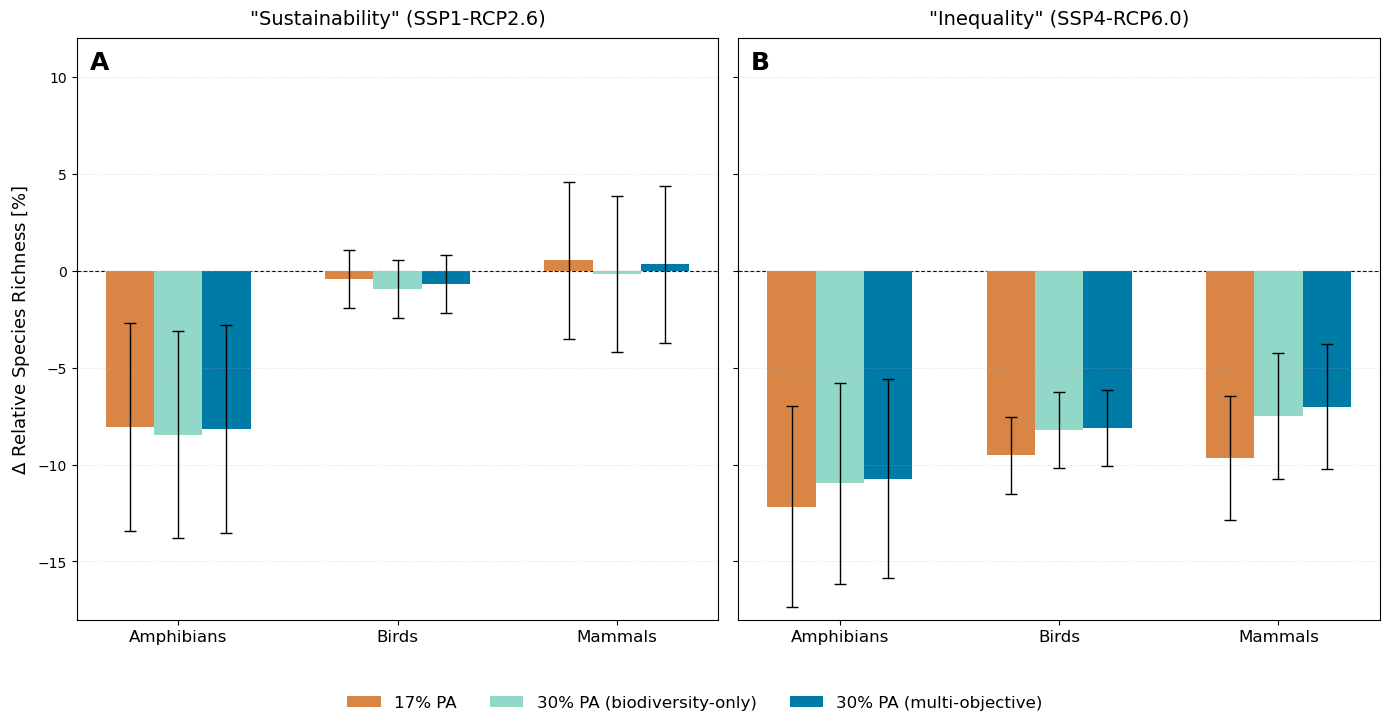

In [17]:
import os
import glob
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt

# --- 1. SETTINGS & PATHS ---
# Using defined folder structure
ROOT_17 = "/capacity/occr_davin/mguzman/chari_P2_review/Global/PA_scenarios/Sumprob/WDPA"
ROOT_BIO = "/capacity/occr_davin/mguzman/chari_P2_review/Global/PA_scenarios/Sumprob/PA30_Bio_new"
ROOT_BCW = "/capacity/occr_davin/mguzman/chari_P2_review/Global/PA_scenarios/Sumprob/PA30_BCW_new"

taxas = ["Amphibians", "Bird", "Mammals"]
# Mapping dictionary
taxa_display = {"Amphibians": "Amphibians", "Bird": "Birds", "Mammals": "Mammals"}
scenarios = ["rcp26", "rcp60"]
scenarios = ["rcp26", "rcp60"]

# Categories to plot
cats = ["17", "biodiversity-only", "multi-objective"]

# Dictionaries to store values
relative_differences = {s: {t: {c: None for c in cats} for t in taxas} for s in scenarios}
std_devs = {s: {t: {c: 0 for c in cats} for t in taxas} for s in scenarios}

# --- 2. DATA EXTRACTION ---
for t in taxas:
    # Historical baseline for normalization
    hist_file = os.path.join(ROOT_17, f"Historical/Ensembles/{t}_historical_2015.nc")
    with xr.open_dataset(hist_file) as ds_hist:
        weights = np.cos(np.deg2rad(ds_hist.lat))
        h_val_taxa = ds_hist['prob_clim_disp_luf'].weighted(weights).mean().item()

    for sce in scenarios:
        # Glob patterns for the three expansion types
        f_lists = {
            "17":  glob.glob(f"{ROOT_17}/Baseline/summed_prob_{t}_*_{sce}_2080_wdpa17.nc"),
            "biodiversity-only": glob.glob(f"{ROOT_BIO}/summed_prob_{t}_*_{sce}_2080_pa30_bio.nc"),
            "multi-objective": glob.glob(f"{ROOT_BCW}/summed_prob_{t}_*_{sce}_2080_pa30_bcw.nc")
        }
        
        def calculate_impact(file_list, reference):
            res = []
            for f in file_list:
                if "Bird_GBM" in f: continue
                with xr.open_dataset(f) as ds:
                    v = ds['prob_clim_disp_luf'].weighted(weights).mean().item()
                    res.append((v - reference) / reference * 100)
            return res

        for c in cats:
            samps = calculate_impact(f_lists[c], h_val_taxa)
            if samps:
                relative_differences[sce][t][c] = {
                    "median": np.median(samps),
                    "mean": np.mean(samps)
                }
                std_devs[sce][t][c] = np.std(samps, ddof=1)

# --- 3. PLOTTING ---
colors = {
    "17":  "#d88546",  # Baseline orange
    "biodiversity-only": "#92d8c8",  # Bio Only blue aqua
    "multi-objective": "#007BA7",  # BCW blue
}

fig, axes = plt.subplots(1, 2, figsize=(14, 7), sharey=True)
titles = {"rcp26": '"Sustainability" (SSP1-RCP2.6)', "rcp60": '"Inequality" (SSP4-RCP6.0)'}
labels = ['A', 'B']

for i, sce in enumerate(scenarios):
    ax = axes[i]
    x = np.arange(len(taxas))
    
    # Adjusted for 3 bars
    bar_width = 0.22
    offsets = [-bar_width, 0, bar_width]

    for idx, c in enumerate(cats):
        vals = [relative_differences[sce][t][c]["mean"] for t in taxas]
        errs = [std_devs[sce][t][c] for t in taxas]
        leg_lab = "17% PA" if c=="17" else f"30% PA ({c.lower()})"
        
        ax.bar(x + offsets[idx], vals, bar_width, label=leg_lab if i==0 else "", 
               color=colors[c], yerr=errs, capsize=4, error_kw={'elinewidth':1})

    # Labels and Titles
    ax.set_title(titles[sce], loc='center', fontsize=14, pad=10)
    
    # 2. Inside Panel Label (A and B)
    # Using transform=ax.transAxes makes (0,0) bottom-left and (1,1) top-right of the plot
    ax.text(0.02, 0.98, labels[i], 
            transform=ax.transAxes, 
            fontsize=18, 
            fontweight='bold', 
            va='top', 
            ha='left',
            bbox=dict(facecolor='white', alpha=0.7, edgecolor='none', pad=2)) # Adds a soft white background for legibility


    ax.set_xticks(x)
    ax.set_xticklabels(taxa_display.values(), fontsize=12)
    ax.axhline(0, color="black", linestyle="--", linewidth=0.8, zorder=0)
    ax.set_ylim(-18, 12) 
    ax.grid(axis='y', linestyle=':', alpha=0.4)
    if i == 0: 
        ax.set_ylabel('$\Delta$ Relative Species Richness [%]', fontsize=13)

# Legend Configuration
handles, plot_labels = axes[0].get_legend_handles_labels()
fig.legend(handles, plot_labels, loc="upper center", ncol=3, 
           bbox_to_anchor=(0.5, 0.02), fontsize=12, frameon=False)

import pandas as pd

# --- 4. SUMMARY TABLE ---
print("\n" + "="*85)
print("SUMMARY TABLE: MEAN % CHANGE ± MODEL UNCERTAINTY (STDEV) PER TAXA")
print("="*85)

summary_rows = []

for sce in scenarios:
    for t in taxas:
        row = {
            'Scenario': titles[sce].split(' (')[0].replace('"', ''), # e.g., Sustainability
            'Taxa': taxa_display[t]
        }
        for c in cats:
            mean_val = relative_differences[sce][t][c]["mean"]
            std_val = std_devs[sce][t][c]
            
            # Formatting column name and value
            col_name = "17% PA" if c == "17" else f"30% PA ({c.upper()})"
            row[col_name] = f"{mean_val:6.2f}% ± {std_val:5.2f}"
            
        summary_rows.append(row)

# Create DataFrame
df_summary = pd.DataFrame(summary_rows)

# Print to console
print(df_summary.to_string(index=False, justify='center'))

# Optional: Export to CSV if needed
df_summary.to_csv("taxa_summary_results.csv", index=False)

plt.tight_layout(rect=[0, 0.05, 1, 1])
plt.show()

Figure 5. Methods diagram

Panel B

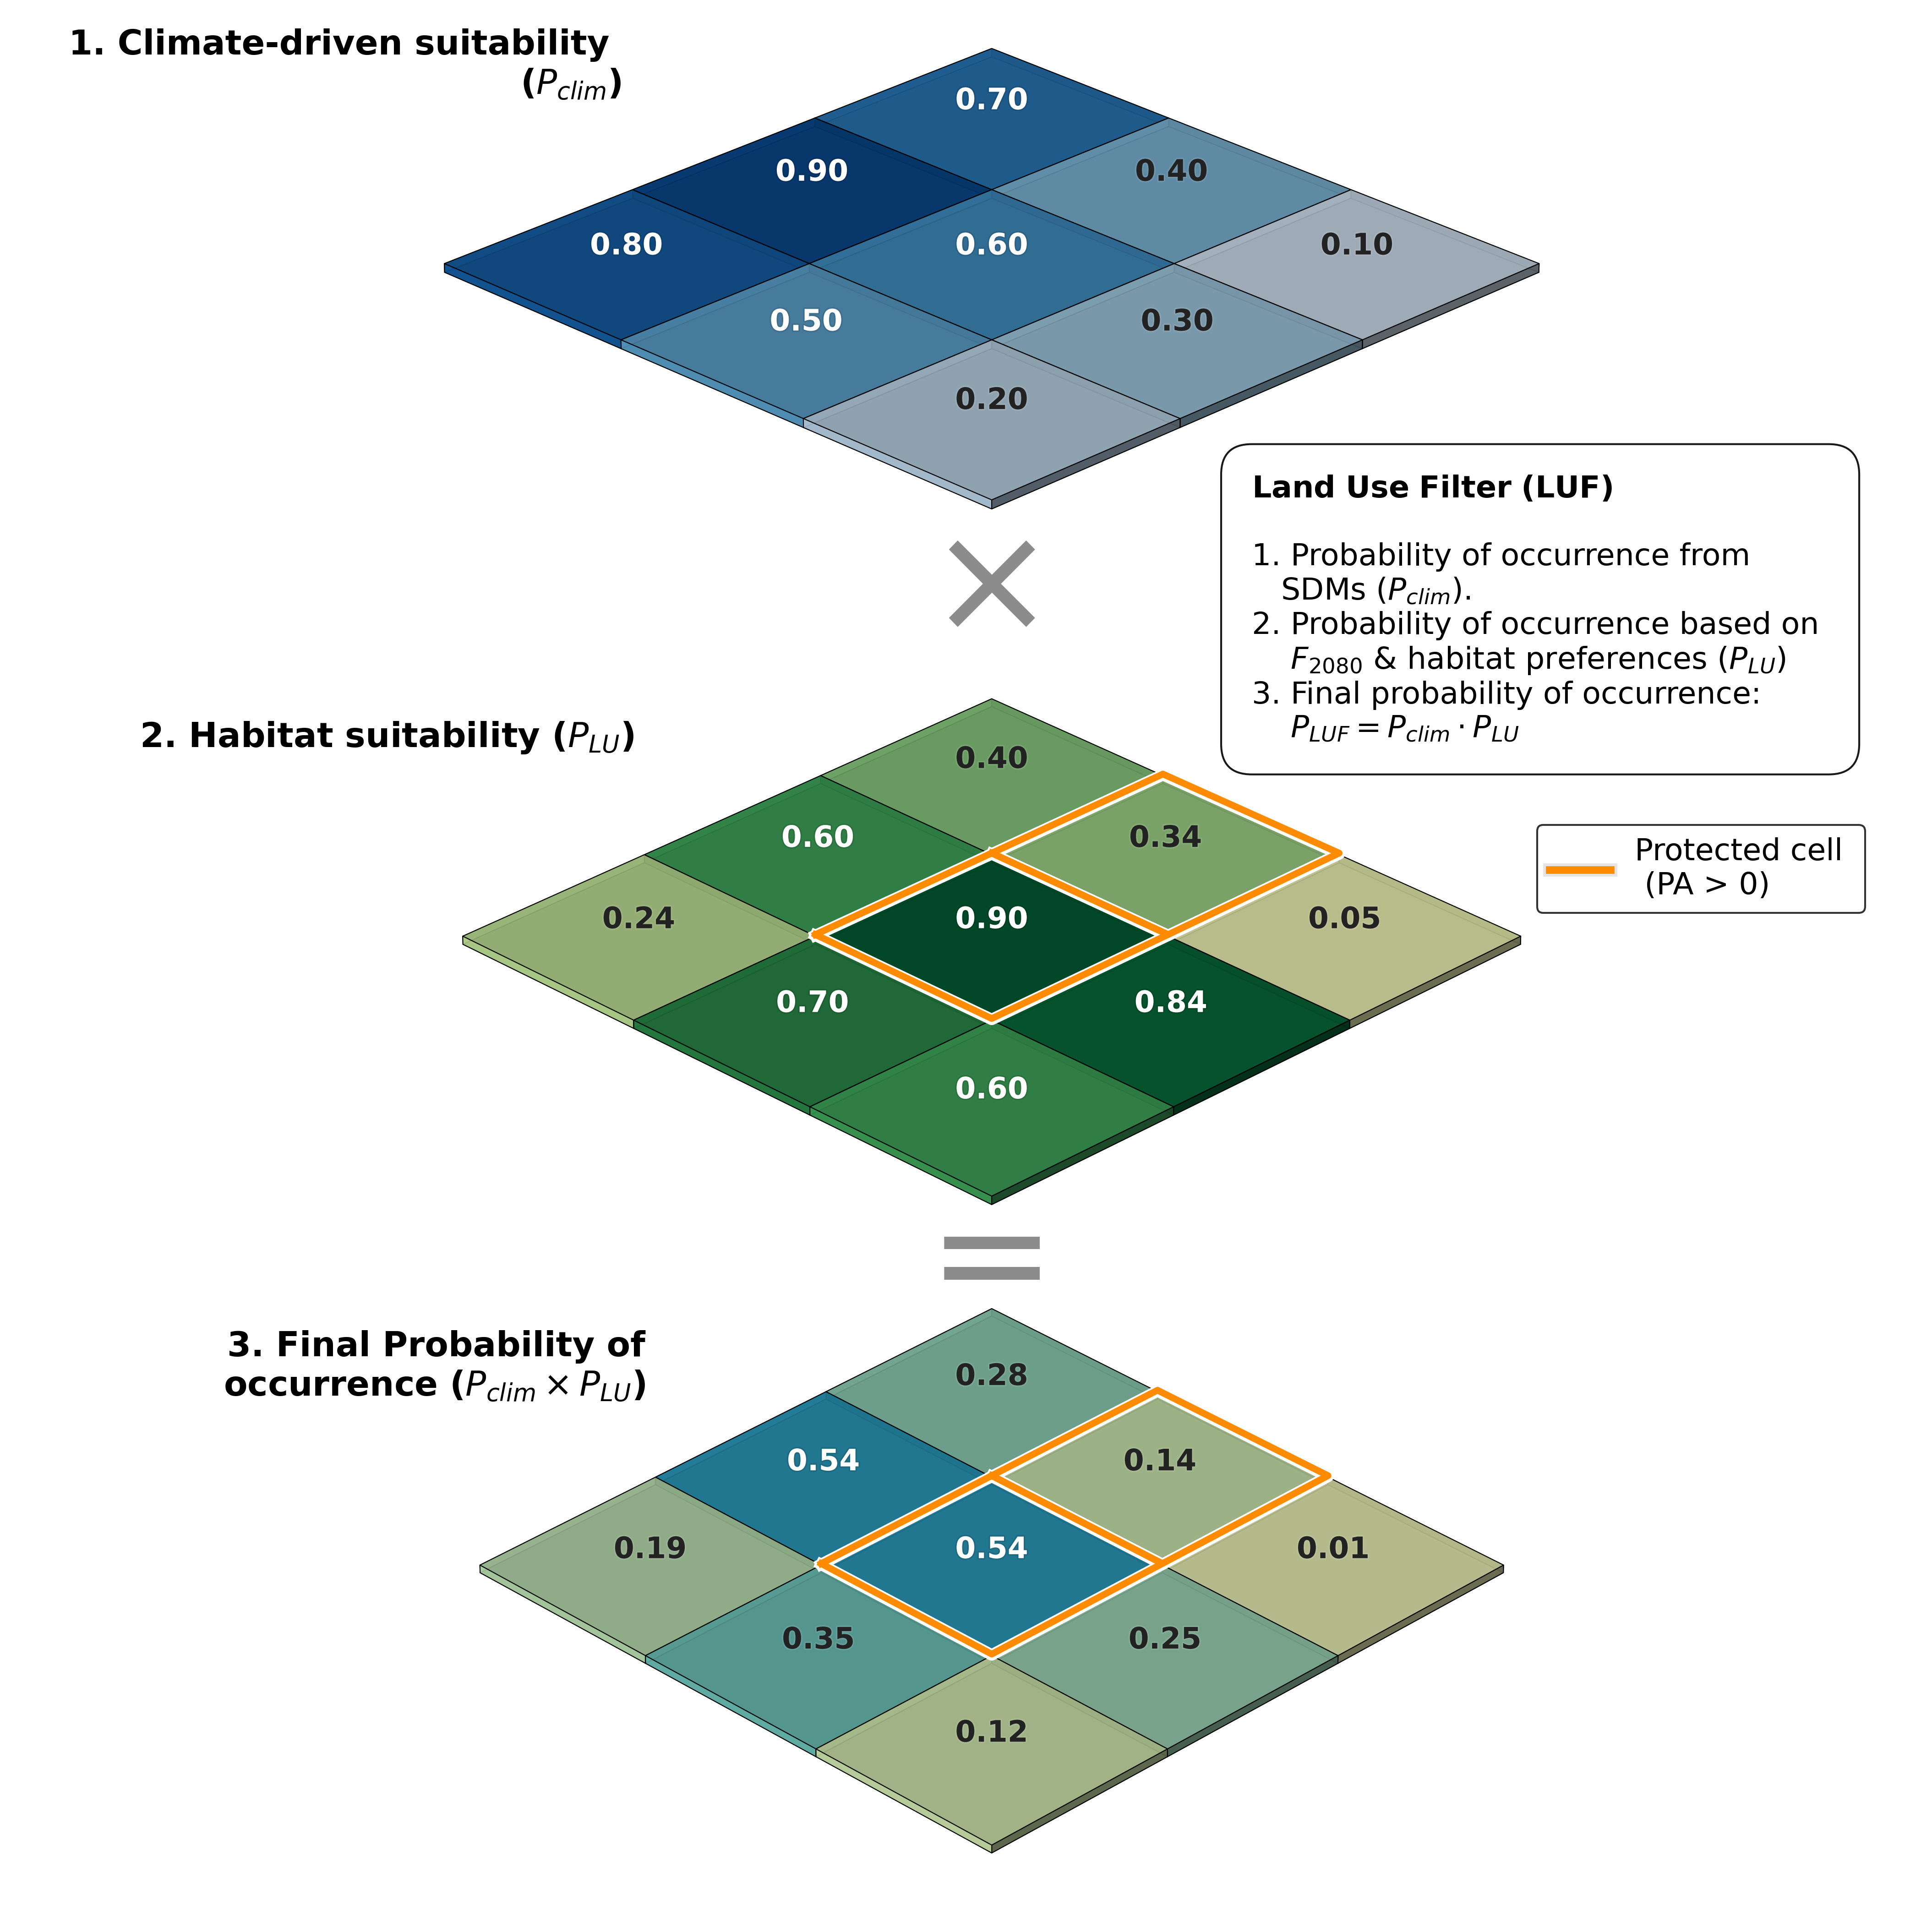

In [134]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import matplotlib.patheffects as path_effects
import matplotlib.colors as mcolors

def plot_luf_sdm_style():
    # 300 DPI for paper-quality resolution
    fig = plt.figure(figsize=(22, 18), dpi=300)
    ax = fig.add_subplot(111, projection='3d')
    ax.view_init(elev=28, azim=-45)

    size = 3 
    
    # 1. DATA LAYERS
    clim = np.array([[0.8, 0.5, 0.2], [0.9, 0.6, 0.3], [0.7, 0.4, 0.1]])
    lu_pa = np.array([[0.24, 0.70, 0.6], [0.6, 0.9, 0.84], [0.40, 0.34, 0.05]])
    result = clim * lu_pa

    # Using a norm to ensure 0.0 is not pure white (light tint)
    norm_data = mcolors.Normalize(vmin=-0.1, vmax=1.0)

    def draw_grid(data, z_offset, cmap, title, show_pa=False, title_lift=2.0):
        x, y = np.meshgrid(np.arange(size), np.arange(size))
        x_f, y_f, data_f = x.flatten(), y.flatten(), data.flatten()
        
        for i in range(len(data_f)):
            val = data_f[i]
            n_val = norm_data(val)
            color = cmap(n_val)
            
            # 1. Base Cells (Plates)
            ax.bar3d(x_f[i], y_f[i], z_offset, 1.0, 1.0, 0.1, 
                     color=color, alpha=0.9, edgecolor='black', linewidth=0.5)
            
            # 2. Dynamic Text Logic: Dark text for light squares, white for dark
            t_color = 'white' if n_val > 0.5 else '#222222'
            txt = ax.text(x_f[i] + 0.5, y_f[i] + 0.5, z_offset + 0.3, f"{val:.2f}",
                    ha='center', va='center', fontsize=15.5, fontweight='bold', 
                    color=t_color, zorder=1000)
            
            # Subtle shadow for text
            txt.set_path_effects([path_effects.withStroke(linewidth=1.5, 
                                 foreground='white' if t_color != 'white' else 'black', alpha=0.1)])
            
            # 3. HIGH-CONTRAST PA HIGHLIGHT
            if show_pa and i in [4, 7]: # Example cells
                lx = [x_f[i], x_f[i]+1.0, x_f[i]+1.0, x_f[i], x_f[i]]
                ly = [y_f[i], y_f[i], y_f[i]+1.0, y_f[i]+1.0, y_f[i]]
                
                # White underlay for contrast
                ax.plot(lx, ly, [z_offset + 0.11]*5, color='white', linewidth=6, zorder=499)
                # Orange highlight
                ax.plot(lx, ly, [z_offset + 0.12]*5, color='#FF8C00', linewidth=3.5, zorder=500)

        # Title
        ax.text(-0.05, 1, z_offset + title_lift, title, 
                ha='right', va='center', fontsize=18, fontweight='bold', color='black')

    # --- RENDER LAYERS ---
    draw_grid(clim, 16, plt.cm.Blues, "1. Climate-driven suitability \n($P_{clim}$)", title_lift=1.5)
    ax.text(1.5, 1.5, 12.3, "×", fontsize=80, ha='center', va='center', color='gray', alpha=0.9)

    draw_grid(lu_pa, 8, plt.cm.YlGn, "2. Habitat suitability ($P_{LU}$)", show_pa=True, title_lift=1.5)
    ax.text(1.5, 1.5, 4, "=", fontsize=80, ha='center', va='center', color='gray', alpha=0.9)

    draw_grid(result, 0, plt.cm.YlGnBu, "3. Final Probability of\n occurrence ($P_{clim} \\times P_{LU}$)", show_pa=True, title_lift=1.5)

    # --- AESTHETICS ---
    ax.set_box_aspect((1, 1, 1.8)) 
    
    # Legend
    legend_elements = [Line2D([0], [0], color='#FF8C00', lw=4, path_effects=[path_effects.withStroke(linewidth=7, foreground='black', alpha=0.1)], label='Protected cell \n (PA > 0)')]
    ax.legend(handles=legend_elements, loc='lower right', bbox_to_anchor=(0.98, 0.52), 
              fontsize=16, frameon=True, edgecolor='black')

    # Description
    math_desc = (
        "$\\bf{Land\\ Use\\ Filter\\ (LUF)}$\n\n"
        "1. Probability of occurrence from \n   SDMs ($P_{clim}$).\n"
        "2. Probability of occurrence based on \n    $F_{2080}$ & habitat preferences ($P_{LU}$)\n"
        "3. Final probability of occurrence:\n"
        "    $P_{LUF} = P_{clim} \\cdot P_{LU}$"
    )
    ax.text2D(0.65, 0.62, math_desc, transform=ax.transAxes, fontsize=16, 
              bbox=dict(facecolor='white', alpha=0.9, edgecolor='black', boxstyle='round,pad=1'))

    ax.set_axis_off()
    plt.show()

plot_luf_sdm_style()

Panel A

In [137]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import matplotlib.patheffects as path_effects
import matplotlib.colors as mcolors

def plot_panel_a_final():
    # High DPI for publication quality
    # Adjusted figure size for the side-by-side elements
    fig = plt.figure(figsize=(24, 20), dpi=500)
    ax = fig.add_subplot(111, projection='3d')
    ax.view_init(elev=28, azim=-65)

    size = 3
    # Left Stack X-coordinate (The Logic/Drivers)
    LEFT_X = 0 
    # Right Stack X-coordinate (The State Transitions)
    RIGHT_X = 7.5 
    
    # --- DATA SETUP ---
    # PA mask: 0.0 is unprotected, 1.0 is fully protected
    pa_mask = np.array([[0.0, 0.0, 0.0], 
                        [0.0, 1.0, 0.0], 
                        [0.0, 0.6, 0.0]])
    
    # (1 - PA) represents the fraction available for land-use change
    available_mask = 1.0 - pa_mask
    
    baseline_2015 = np.array([[0.2, 1.0, 0.8], 
                              [1.0, 0.9, 0.7], 
                              [0.5, 0.4, 0.1]])
    
    # Projected Change from LUH2 (SSP-RCP dependent)
    raw_delta_luh2 = np.array([[0.04, -0.30, -0.20],
                               [-0.40, -0.35, 0.14],
                               [-0.10, -0.15, -0.05]])
    
    # Realized Change constrained by protection: Delta_forest = Raw * (1 - PA)
    realized_delta = raw_delta_luh2 * available_mask
    
    # Final state: Future = Baseline + Realized Change
    final_2080 = np.clip(baseline_2015 + realized_delta, 0, 1.0)

    # Normalization for color scales
    norm_delta = mcolors.Normalize(vmin=-0.5, vmax=0.5) 
    norm_lu = mcolors.Normalize(vmin=0.0, vmax=1.0)

    def draw_grid(data, x_offset, z_offset, cmap, title, norm, is_change=False, show_pa=False):
        x, y = np.meshgrid(np.arange(size), np.arange(size))
        x_f, y_f, data_f = x.flatten() + x_offset, y.flatten(), data.flatten()
        
        for i in range(len(data_f)):
            val = data_f[i]
            n_val = norm(val)
            
            ax.bar3d(x_f[i], y_f[i], z_offset, 1.0, 1.0, 0.1, 
                     color=cmap(n_val), alpha=0.9, edgecolor='black', linewidth=0.5)

            if cmap == plt.cm.RdBu:
                t_color = '#222222' if 0.3 < n_val < 0.7 else 'white'
            if cmap == plt.cm.Purples:
                t_color = '#222222' if 0.3 > n_val else 'white'
            else:
                t_color = 'white' if n_val > 0.5 or n_val < 0.2 else '#222222'

            txt = ax.text(x_f[i] + 0.5, y_f[i] + 0.4, z_offset + 0.3, f"{val:+.2f}" if cmap == plt.cm.RdBu else f"{val:.2f}",
                    ha='center', va='center', fontsize=15, fontweight='bold', 
                    color=t_color, zorder=1000)
            txt.set_path_effects([path_effects.withStroke(linewidth=1.5, foreground='white' if t_color != 'white' else 'black', alpha=0.1)])
            
            # Draw orange borders for cells with any protection (PA > 0)
            if show_pa and pa_mask.flatten()[i] > 0.01:
                lx = [x_f[i], x_f[i]+1, x_f[i]+1, x_f[i], x_f[i]]
                ly = [y_f[i], y_f[i], y_f[i]+1, y_f[i]+1, y_f[i]]
                ax.plot(lx, ly, [z_offset + 0.11]*5, color='white', linewidth=6, zorder=499, alpha=0.8)
                ax.plot(lx, ly, [z_offset + 0.12]*5, color='#FF8C00', linewidth=3.5, zorder=500)

        # Layer Titles
        ax.text(x_offset + 2, 3.5, z_offset + 0.5, title, 
                ha='center', va='center', fontsize=15, fontweight='bold')

    # --- LEFT STACK: DRIVERS & LOGIC ---
    draw_grid(available_mask, LEFT_X, 8, plt.cm.Purples, "2a. PA mask\n($1 - PA$)", norm_lu)
    draw_grid(raw_delta_luh2, LEFT_X, -2, plt.cm.RdBu, "2b. Projected Change ($\Delta LUH2$)\n (2080-2015)", norm_delta, is_change=True)

    # --- RIGHT STACK: STATE TRANSITIONS ---
    draw_grid(baseline_2015, RIGHT_X, 20, plt.cm.YlGn, "1. Present-day forested \n land ($F_{2015}$)", norm_lu, show_pa=False)
    draw_grid(realized_delta, RIGHT_X, 8, plt.cm.RdBu, "2. Realized Change\n($\Delta_{F}$)", norm_delta, is_change=True, show_pa=True)
    draw_grid(final_2080, RIGHT_X, -5, plt.cm.YlGn, "3.  Future forested land \n ($F_{2080}$)", norm_lu, show_pa=True)

    # --- FIGURE AESTHETICS ---
    ax.set_box_aspect((3.5, 3.1, 3.5)) 
    ax.set_xlim(-1, 10) 
    ax.set_ylim(-1, 5)
    ax.set_zlim(-6, 15)
    ax.set_axis_off()

    legend_elements = [Line2D([0], [0], color='#FF8C00', lw=4, label='Protected cell \n (PA > 0)')]
    ax.legend(handles=legend_elements, loc='lower right', bbox_to_anchor=(0.2, 0.2), 
              fontsize=15, frameon=True, edgecolor='black')

    math_desc = (
        "$\\bf{PA\\ full-effectiveness}$\n\n"
        "1. Present-day land-use from LUH2\n"
        "2. Apply PA mask to restrict projected \n land-use change ($\Delta LUH2$):\n"
        "   $\\Delta_{F} = \\Delta_{LUH2} \\cdot (1 - PA)$\n\n"
        "$\\bullet$ $\\bf{Full\\ Protection}$ ($PA=1.0$):\n"
        "   Projected change is blocked ($\\Delta = 0$).\n"
        "$\\bullet$ $\\bf{Partial\\ Protection}$ ($PA=0.6$):\n"
        "   Only 40% of the projected change occurs.\n\n"
        "3. Future proportion of forested land per grid cell\n"
        "$F_{2080} = F_{2015} + \\Delta_{F}$"
    )
    ax.text2D(0.02, 0.75, math_desc, transform=ax.transAxes, fontsize=16, 
              bbox=dict(facecolor='white', alpha=0.9, edgecolor='black', boxstyle='round,pad=1'))
    
    # Save as high-resolution TIFF
    plt.savefig('Panel_A_Fig5.tiff', dpi=600, bbox_inches='tight', format='tiff')
    plt.show()

plot_panel_a_final()

Supplementary Fig. 1. Spatial distribution of PA scenarios (17%-PA, 'biodiversity-only', 'multi-objective')

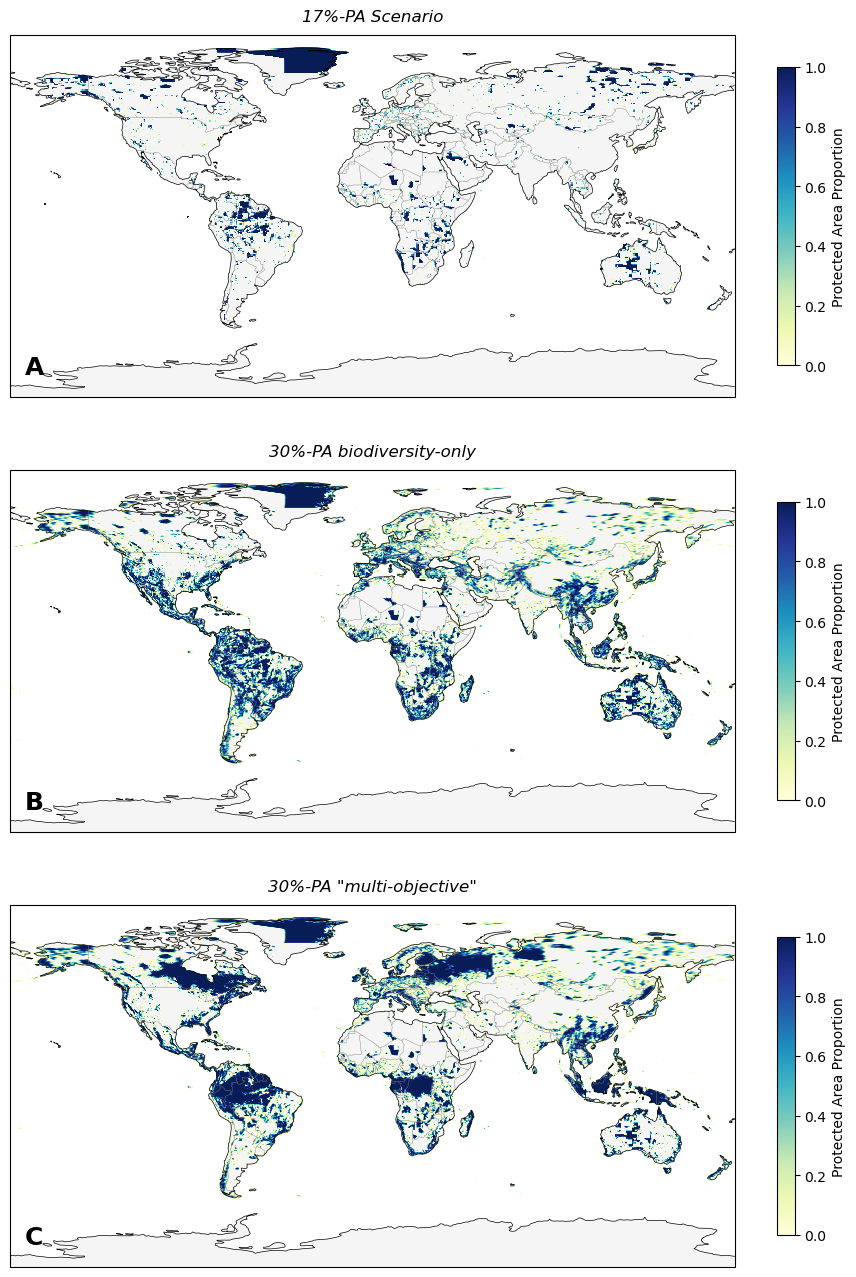

In [ ]:
import xarray as xr
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from mpl_toolkits.axes_grid1 import make_axes_locatable

# Define file paths
paths = {
    'A': '/capacity/occr_davin/mguzman/chari_P2_review/data/PA_masks/WDPA_percentage_map.nc',
    'B': '/capacity/occr_davin/mguzman/chari_P2_review/data/PA_masks/bio-only_withPA.nc',
    'C': '/capacity/occr_davin/mguzman/chari_P2_review/data/PA_masks/bcw_withPA.nc'
}

# Setup figure
titles = ['17%-PA Scenario', 
          '30%-PA biodiversity-only', 
          '30%-PA "multi-objective"']

fig, axes = plt.subplots(3, 1, figsize=(12, 16), 
                         subplot_kw={'projection': ccrs.PlateCarree()})

for i, (ax, (key, path)) in enumerate(zip(axes, paths.items())):
    ds = xr.open_dataset(path)
    var_name = list(ds.data_vars)[0]
    data = ds[var_name]
    
    # Normalize WDPA values
    if key == 'A':
        data = data / 100.0
    
    data_masked = data.where(data > 0)
    
    # Add features
    ax.add_feature(cfeature.LAND, facecolor='whitesmoke', zorder=0)
    ax.add_feature(cfeature.COASTLINE, linewidth=0.5, zorder=2)
    ax.add_feature(cfeature.BORDERS, linewidth=0.3, edgecolor='gray', zorder=2)
    ax.set_global()
    
    # Plotting
    im = data_masked.plot(ax=ax, transform=ccrs.PlateCarree(),
                          vmin=0, vmax=1, cmap='YlGnBu',
                          add_colorbar=False, zorder=1)
    
    # Set Title: Italics, centered, and above the map
    ax.set_title(titles[i], style='italic', fontsize=13, pad=10)
    
    # Add Panel Label (A, B, C) inside the map at the bottom left
    # transform=ax.transAxes uses 0-1 coordinates relative to the plot box
    ax.text(0.02, 0.05, key, transform=ax.transAxes, 
            fontsize=18, fontweight='bold', va='bottom', ha='left', zorder=3)

    # Use make_axes_locatable with a projection-aware workaround
    # This places the colorbar strictly to the right of the individual axis
    pos = ax.get_position()
    cax = fig.add_axes([pos.x1 + 0.01, pos.y0 + 0.02, 0.015, pos.height - 0.04])
    cbar = fig.colorbar(im, cax=cax)
    cbar.set_label('Protected Area Proportion', fontsize=10)

# Adjust subplots
plt.subplots_adjust(right=0.85, hspace=0.2)

plt.savefig('Global_PA_Scenarios_Final.pdf', dpi=300, bbox_inches='tight')
plt.show()